# EDIS 8100 · Week 11 · Co-Design Studio

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

This is the last notebook of the semester. Our guest this week is Zifeng Liu,
University of Florida, who joins us from 4:30 to 5:30.

**There is no in-class notebook block this week.** The session is an opening, the reading
discussion, a break, the guest lecture and Q&A, then a guest debrief with rough draft work time and
the close of the discussion leadership arc. You work through this notebook on your own this week,
before or after we meet, at whatever pace suits you.

If Python is new to you, that is completely fine. Every cell here already contains working code, and
there is no expectation that you write code from scratch, today or in any week of this course. Your
attention is better spent on what the code is doing to the data and on what the output might mean.
Questions are welcome at any point, including questions about a single line of code.

Nothing from this notebook is collected. The Course Research Project Rough Draft is due this week
and goes to Canvas separately.

### What I hope you leave with

1. A way of holding stakeholders as data: persona cards that carry goals, fears, and decision
   rights, and a sense of why decision rights change what a metric is allowed to mean.
2. A comparison of four "top 500" lists built from four defensible measures of the same enrollments,
   read against what chance and course composition alone would produce.
3. Some practice reading your own sketch as a second persona would, with a file that records what
   learners said at registration they expected to do.
4. An audit of our own semester: artifact by artifact from weeks 1 through 11, who might have had a
   voice in the design.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- This runs on a temporary machine in the cloud, working on a copy of a published file. If something
  goes wrong, `Runtime > Restart session and run all` resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without
  editing anything and nothing will be missing.
- The section marked **Going further** near the end is optional. Please feel free to skip it today.
- A few cells pause for five or ten seconds, because they repeat a calculation a few hundred times
  in order to put an interval around it.

### The route

This notebook is worked through outside class rather than opened in class, so the route below is
for working alone. It says what to do first when the time available is short.

| | Sections | What it is for |
|---|---|---|
| **CORE, about 55 to 60 minutes** | Setup; 1. The mess, before anything else; 2. The personas as data; 3. The candidate metrics; 4. Your turn, run with the values already in it; 5. The leaderboards, steps 1 to 4 and Holding the course constant; 6. The swap; 7. Retroactive design audit; Reflection | Provenance and what de-identification removed, the columns recorded for a minority of enrollments and the column with two label sets, the four persona cards, the common population and which measures can rank at all, one sketch read for one enrollment, the four top-500 lists against a uniform and a course-matched baseline, the actionability table and what people said at registration, and the audit of weeks 1 to 11 |
| **IF TIME** | The correlation check at the end of section 5; editing `MY_PERSONA` and `MY_METRICS` and re-running the sketch and the swap; moving an audit score in section 7 and re-running | Spearman and Pearson beside the top-500 result, a second persona's sketch and critique, and what one moved score does to the column totals |
| **EXPLORE LATER** | Going further, with its worked example; the appendix of worked examples | The fifth persona this platform has no column for, the refusal list, the two corners where two measures disagree about one enrollment, and the notes on the Your turn cells |

The four objectives above are met on the CORE path.

**What is and is not assessed.** Nothing in this notebook is collected or graded, and coding skill
is not what is assessed anywhere in this course. What is worth your attention here is the reading
you give the output: what a measure can see, what it cannot, and what the output might mean.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to
read the code the way you read a methods section: you are checking what was done to the data, not
memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in
`df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`,
`.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line does
not make sense, please ask.

## Setup

| | |
|---|---|
| **Dataset** | Canvas Network Person-Course (1/2014 - 9/2015) De-Identified Open Dataset |
| **Who collected it** | Canvas Network, the open-course arm of the educational technology company Instructure, from its own platform logs and its own intake survey |
| **What one row is** | One person's activity in one course. 325,199 rows, 26 columns, 238 courses, January 2014 to September 2015 |
| **License** | **CC BY 4.0.** Free to use, share and adapt, including commercially, with attribution |
| **Where it lives** | Harvard Dataverse, `doi:10.7910/DVN/1XORAL`, deposited February 2016 |
| **How we get it** | The next code cell downloads one 3 MB file from `github.com/HakeoungLee/edis8100-datasets` |

**Citation.** Canvas Network. (2016). *Canvas Network Person-Course (1/2014 - 9/2015)
De-Identified Open Dataset* [Data set]. Harvard Dataverse. https://doi.org/10.7910/DVN/1XORAL

**Who these people are, and what they were told.** Canvas Network hosted free, open online courses
that anyone could join. The people in this file registered for a course on the open internet, and
their activity was logged because logging is what a learning platform does. Some of them also
answered a short survey at registration. The file was assembled from Canvas Network's own platform
records and its registration survey rather than from a study that recruited participants, and the
release documents record no consent process for publication (Canvas Network, 2016,
*De-Identification*). Instructure anonymized the file, dropped or blurred the fields that could
identify someone, and published it so that people outside the company could learn something from it.
The release excluded every user who reported an age under 18, so the file is a record of adults who
said so at registration. It also excluded the courses whose organizations or instructors opted out
of the project, so the 238 courses are the ones that did not (Canvas Network, 2016,
*De-Identification*).

**What the anonymization cost.** Three columns arrive empty or flattened. Country was replaced by a
single `*` on every row. Gender was withheld entirely. Age survives only as a bracket. The
de-identification document records that country yielded no useful values after de-identification and
was omitted, and that the process removed gender and country of origin (Canvas Network, 2016,
*De-Identification*, pp. 2 to 3). The first code cell shows which columns are affected.

**Run the cell below.** It fetches one file over the internet and prints what arrived.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

# Okabe-Ito, a palette designed to stay distinguishable for the most common
# forms of color vision deficiency. Every figure in this notebook uses it.
BLUE, ORANGE, GREEN, PINK = '#0072B2', '#E69F00', '#009E73', '#CC79A7'
SKY, VERM, YELLOW, GREY = '#56B4E9', '#D55E00', '#F0E442', '#999999'

URL = ('https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/'
       'main/canvas-network/person_course.csv.gz')

pc = None
try:
    pc = pd.read_csv(URL, low_memory=False)
except Exception as err:
    print('Could not download the data file.')
    print()
    print('The notebook was trying to read:')
    print('   ' + URL)
    print()
    print('This is almost always one of three things:')
    print('  1. no internet connection in this runtime;')
    print('  2. a firewall between you and github.com;')
    print('  3. the course dataset repository github.com/HakeoungLee/edis8100-datasets')
    print('     moved or was renamed.')
    print()
    print('Try Runtime > Restart session and run all first. If it still fails, please let the')
    print('instructor know, and paste this line so she can see which of the three it was:')
    print('   ' + type(err).__name__ + ': ' + str(err)[:160])

if pc is not None:
    print('Downloaded the Canvas Network person-course file.')
    print()
    print('   {:,} rows and {} columns'.format(pc.shape[0], pc.shape[1]))
    print('   {:,} distinct courses'.format(pc['course_id_DI'].nunique()))
    print('   {:,} distinct people'.format(pc['userid_DI'].nunique()))
    print('   courses starting {} through {}'.format(sorted(pc['course_start'].unique())[0],
                                                     sorted(pc['course_start'].unique())[-1]))
    print()
    print('One row is one person in one course. Ready.')

Downloaded the Canvas Network person-course file.

   325,199 rows and 26 columns
   238 distinct courses
   224,914 distinct people
   courses starting 2014 Q1 through 2015 Q3

One row is one person in one course. Ready.


## 1. The mess, before anything else

This file came out of a company's production database by way of an anonymization pipeline, and the
shape of that shows in the columns.

We look at the mess **first**, on purpose, because two of the decisions we make here change every
number this notebook reports about the intake survey.

What to look for:

1. **Columns that arrive empty.** Anonymization removed some, and the platform never recorded
   others.
2. **Columns that are recorded for a minority of rows.** Most of the interesting measures exist for
   a quarter of the file or less, and *which* quarter is not random.
3. **A column with two sets of labels.** One survey question got two different sets of answer
   labels, and nothing in the file tells you they are the same question.

**Run the cell below** for the first of the three.

In [1]:
# Which columns carry no information at all?
print('Columns that hold exactly one value on all {:,} rows:'.format(len(pc)))
for col in pc.columns:
    vals = pc[col].dropna().unique()
    if len(vals) == 1:
        print('   {:<20} every row says {!r}'.format(col, vals[0]))
print()
print('age_DI holds the same empty-brace sentinel on {:,} of {:,} rows ({:.1f} percent);'.format(
    int((pc['age_DI'] == '{}').sum()), len(pc), 100 * (pc['age_DI'] == '{}').mean()))
print('{:,} rows carry an age bracket.'.format(int((pc['age_DI'] != '{}').sum())))
print()
print('`registered` is 1 everywhere because the file only contains registrations.')
print('`final_cc_cname_DI` (country) and `gender` were withheld to protect the people in the file.')
print('The consequence is concrete: any fairness question you might want to ask about gender')
print('or country cannot be asked here, because the release removed them during')
print('de-identification (see the de-identification document filed with the dataset).')
print('Week 3 asked those questions of a dataset that allowed them.')

Columns that hold exactly one value on all 325,199 rows:
   registered           every row says 1
   final_cc_cname_DI    every row says '*'
   gender               every row says '{}'

age_DI holds the same empty-brace sentinel on 288,119 of 325,199 rows (88.6 percent);
37,080 rows carry an age bracket.

`registered` is 1 everywhere because the file only contains registrations.
`final_cc_cname_DI` (country) and `gender` were withheld to protect the people in the file.
The consequence is concrete: any fairness question you might want to ask about gender
or country cannot be asked here, because the release removed them during
de-identification (see the de-identification document filed with the dataset).
Week 3 asked those questions of a dataset that allowed them.


**Run the cell below.** It asks how much of each column is recorded at all, as a table and then as
a figure.

                     rows recorded of 325,199
completed_%                  26661       8.2%
nforum_posts                 37091      11.4%
learner_type                 38371      11.8%
primary_reason               38371      11.8%
expected_hours_week          38371      11.8%
LoE_DI                       38371      11.8%
ncontent                     41312      12.7%
grade                        82002      25.2%
nevents                      86287      26.5%
last_event_DI                92173      28.3%
start_time_DI                99844      30.7%
ndays_act                   101234      31.1%

Every other column has a value on all 325,199 rows, although three of them hold a
placeholder rather than a measurement: country is "*", gender and age_DI are "{}"
wherever nothing was released.


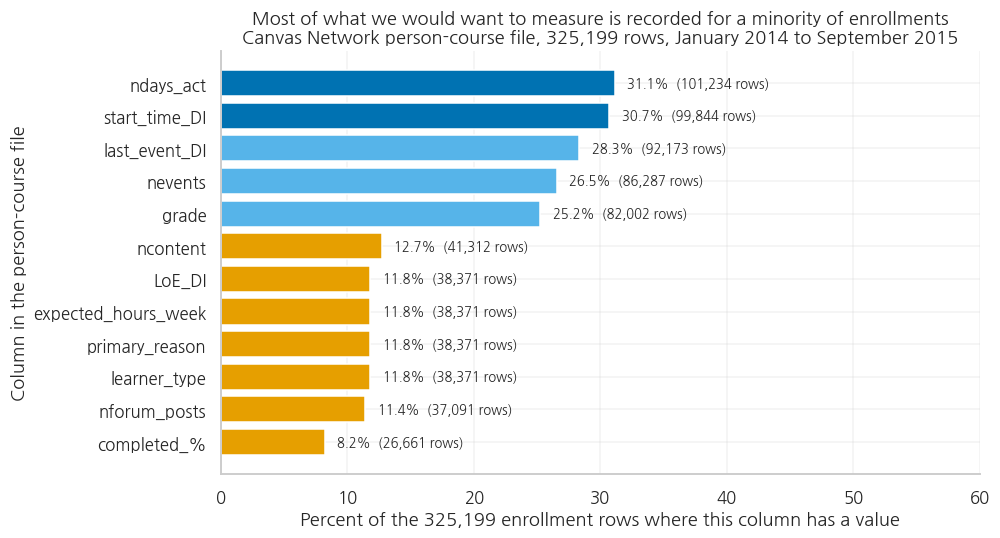

In [2]:
# How much of each column is actually recorded?
recorded = (pc.notna().sum() / len(pc) * 100).sort_values()
interesting = ['completed_%', 'nforum_posts', 'learner_type', 'primary_reason',
               'expected_hours_week', 'LoE_DI', 'ncontent', 'grade', 'nevents',
               'last_event_DI', 'start_time_DI', 'ndays_act']

tbl = pd.DataFrame({
    'rows recorded': pc[interesting].notna().sum(),
    'of 325,199': ['{:.1f}%'.format(recorded[c]) for c in interesting],
})
print(tbl.to_string())
print()
print('Every other column has a value on all {:,} rows, although three of them hold a'.format(len(pc)))
print('placeholder rather than a measurement: country is "*", gender and age_DI are "{}"')
print('wherever nothing was released.')

fig, ax = plt.subplots(figsize=(9.2, 5.0))
share = pc[interesting].notna().mean() * 100
colors = [ORANGE if v < 15 else (SKY if v < 30 else BLUE) for v in share]
bars = ax.barh(interesting, share, color=colors, edgecolor='white')
for bar, v, n in zip(bars, share, pc[interesting].notna().sum()):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            '{:.1f}%  ({:,} rows)'.format(v, n), va='center', fontsize=8.5)
ax.set_xlim(0, 60)
ax.set_xlabel('Percent of the 325,199 enrollment rows where this column has a value')
ax.set_ylabel('Column in the person-course file')
ax.set_title('Most of what we would want to measure is recorded for a minority of enrollments\n'
             'Canvas Network person-course file, 325,199 rows, January 2014 to September 2015')
plt.tight_layout()
plt.show()

**Let's look at the output.** Most of what a designer would want to measure exists for a minority of
these enrollments, and `ncontent`, the percent of the course modules a person reached, is recorded
on 12.7 percent of rows.

1. **The instrument.** `nevents` is a count of recorded page views. A blank is not "this person did
   nothing", it is "this platform wrote nothing down for this person in this course". `grade` exists
   only for courses that had enough scored activities to compute one, which is a fact about the
   *course*, not the learner. `ncontent` requires the course to be built out of modules (Canvas
   Network, 2016, data dictionary).
2. **The setting.** These are open online courses that the documentation describes as freely
   available to anyone (Canvas Network, 2016). A registration here is not the same act as a
   registration in EDIS 8100.
3. **The circumstances.** The file records nothing about the lives these people were living while
   the log was being written.

Which of the three seems to you the most plausible account of the 12.7 percent on `ncontent`, and
what would you want to know about these courses before choosing between them?

*Connecting to the readings.* Carvalho, Martinez-Maldonado, Tsai, Markauskaite, and De Laat (2022)
argue that designing for learning starts from the activity, its purposes, and its setting rather than
from the traces a system happens to produce. This chart is a picture of the traces that were
produced. It may be useful to ask which of these columns exists because someone designed for it, and
which exists because a web server writes it down anyway.

### The column with two sets of labels

At registration, Canvas Network asked people what kind of participant they expected to be, and the
answers are in `learner_type`. **Run the cell below**, and the labels do not line up.

In [3]:
print(pc['learner_type'].value_counts(dropna=False).to_string())
print()
print('`Active` and `Active participant` are almost certainly the same answer with two different')
print('label wordings, and the same for `Passive`. Before we merge them we should check whether')
print('any single course ever used both, because if one did, they are more likely to be two')
print('genuinely different options.')
print()

real = pc[pc['learner_type'].notna() & (pc['learner_type'] != 'Missing')]
short_lbl, long_lbl = {'Active', 'Passive'}, {'Active participant', 'Passive participant'}
by_course = real.groupby('course_id_DI')['learner_type'].apply(
    lambda s: (len(set(s) & short_lbl) > 0, len(set(s) & long_lbl) > 0))
n_short = sum(1 for a, b in by_course if a and not b)
n_long = sum(1 for a, b in by_course if b and not a)
n_both = sum(1 for a, b in by_course if a and b)
print('Courses using the short labels only :', n_short)
print('Courses using the long  labels only :', n_long)
print('Courses using BOTH sets of labels   :', n_both)

learner_type
NaN                    286828
Active                  11782
Passive                 10253
Active participant       4387
Passive participant      3329
Missing                  3261
Drop-in                  2820
Observer                 2539

`Active` and `Active participant` are almost certainly the same answer with two different
label wordings, and the same for `Passive`. Before we merge them we should check whether
any single course ever used both, because if one did, they are more likely to be two
genuinely different options.

Courses using the short labels only : 112
Courses using the long  labels only : 33
Courses using BOTH sets of labels   : 0


**The decision, made in view.** Not one course of the 145 used both vocabularies. That is what we
would see if the survey wording changed once and every course inherited whichever version was live
when it launched. So we merge: `Active` becomes `Active participant`, `Passive` becomes `Passive
participant`.

**What the decision costs.** We cannot verify the merge. No course ran both wordings, so there is no
overlap anywhere in the file where the two labels describe the same people and we could check that
they behave alike. We are assuming it on the strength of the wording and the clean course-level
split, and if we are wrong we have just pooled two different questions.

Two more small decisions, made the same way:

- **`Missing` is a value, not a blank.** 3,261 rows literally say `Missing` in `learner_type`. We
  drop them from the survey analysis and we say how many, rather than letting them quietly become a
  category.
- **We keep the survey rows as rows, not as people.** One person can enroll in several courses and
  answer the survey several times. We will report both counts every time it matters.

**Run the cell below.**

In [4]:
MERGE = {'Active': 'Active participant', 'Passive': 'Passive participant'}
PLAN_ORDER = ['Active participant', 'Passive participant', 'Drop-in', 'Observer']

survey = pc[pc['learner_type'].notna() & (pc['learner_type'] != 'Missing')].copy()
survey['plan'] = survey['learner_type'].replace(MERGE)

n_missing_label = int((pc['learner_type'] == 'Missing').sum())
print('Rows dropped because learner_type literally said "Missing":', n_missing_label)
print()
print('Declared plan at registration, after the merge:')
counts = survey['plan'].value_counts().reindex(PLAN_ORDER)
people = survey.groupby('plan')['userid_DI'].nunique().reindex(PLAN_ORDER)
print(pd.DataFrame({'enrollments': counts, 'distinct people': people}).to_string())
print()
print('Total: {:,} enrollments from {:,} distinct people.'.format(len(survey),
                                                                survey['userid_DI'].nunique()))
print('That is {:.1f} percent of the {:,} rows in the file.'.format(
    100 * len(survey) / len(pc), len(pc)))
print()
print('**Anyone who reasons from these answers is reasoning about respondents.**')
print('The other {:.1f} percent of the file never answered, and we have no way to know'.format(
    100 - 100 * len(survey) / len(pc)))
print('whether they would have answered the same way. This is the same warning as Week 5,')
print('where about eleven annotated spans come from each of 5,531 essays, and Week 9, where eight groups')
print('carried the whole finding. Range restriction belongs in the finding rather than in')
print('a footnote.')

Rows dropped because learner_type literally said "Missing": 3261

Declared plan at registration, after the merge:
                     enrollments  distinct people
plan                                             
Active participant         16169            14364
Passive participant        13582            12327
Drop-in                     2820             2700
Observer                    2539             2442

Total: 35,110 enrollments from 30,336 distinct people.
That is 10.8 percent of the 325,199 rows in the file.

**Anyone who reasons from these answers is reasoning about respondents.**
The other 89.2 percent of the file never answered, and we have no way to know
whether they would have answered the same way. This is the same warning as Week 5,
where about eleven annotated spans come from each of 5,531 essays, and Week 9, where eight groups
carried the whole finding. Range restriction belongs in the finding rather than in
a footnote.


## 2. The personas as data

A persona is not a demographic sketch. For design purposes the useful parts of a person are:

- **Goals**: what they are actually trying to accomplish.
- **Fears**: what a bad version of this tool would do to them.
- **Decision rights**: what they are allowed to change once they see the number. This is the part
  most dashboards skip, and it is the part Bang and Vossoughi (2016) would say carries the power
  relations. A metric handed to someone with no authority to act on it puts pressure on them without
  telling them anything they can use.
- **Grain**: whether they need the whole platform at once, one course, or one person.
- **Access reality**: what they would actually be allowed to see. Sometimes the answer is "nothing",
  and that is a design finding rather than an obstacle.
- **Their measure**: the one number each of them would reach for first. All four are in this file,
  which is what makes today's exercise possible.

Four people stand around an open online course: the two people who made it, the company that hosts
it, the foundation that paid for it, and the person it is supposedly for. It may be worth noticing
which of the four can see the least.

**Run the cell below** for the four cards.

In [5]:
PERSONAS = {
    'teacher': dict(
        name='Dana Okonkwo', measure='grade',
        role='Course team lead. Built and ran an open course with one colleague and no budget.',
        goals=[
            'Find out whether the course did anything for anyone, before deciding to run it again',
            'Work out which two modules to cut, because the course is too long and she knows it',
        ],
        fears=[
            'Being judged on a completion rate made mostly of people she never met',
            'A number that says the course failed when it did exactly what people came for',
            'Reading a low grade as a fact about a person rather than about her own assessment design',
        ],
        decision_rights=[
            'What the course contains and in what order',
            'What counts as complete, and where the certificate threshold sits',
            'What the welcome message says the course is for',
        ],
        cannot_change=['Who registers', 'What the platform logs', 'Whether anyone finishes'],
        grain='one course',
        access_reality='Sees her own course dashboard. Sees nothing about the same person in any other course.',
        question='Did this course do anything for anyone, and how would I know?'),
    'learner': dict(
        name='Malik Ferrer', measure='ncontent',
        role='Adult enrollee. Signed up on a Tuesday, works full time, answered the intake survey.',
        goals=[
            'Get to the two topics he actually signed up for',
            'Decide by the end of week two whether this is worth his evenings',
        ],
        fears=[
            'Being counted as somebody\'s "dropout" for doing exactly what he said he would do',
            'A completion number following him somewhere he cannot see it',
            'Being compared with people who wanted something different from the same course',
        ],
        decision_rights=[
            'Whether to open the course tonight',
            'Which modules to read and which to skip',
            'Whether to answer the intake survey, and how honestly',
        ],
        cannot_change=['Anything about the course', 'Anything about the platform',
                       'What is recorded about him'],
        grain='himself',
        access_reality=('Sees a progress bar if the course has one. Sees none of the rest, '
                        'and was never told this file would exist.'),
        question='Did I get what I came for, and is anything here even about that?'),
    'platform': dict(
        name='Tobias Lindqvist', measure='nevents',
        role='Analytics lead at the company hosting the courses. Reports to leadership and to partners.',
        goals=[
            'Show partner institutions that the platform is being used',
            'Find which courses hold attention, so engineering time goes somewhere defensible',
        ],
        fears=[
            'A quarter where usage falls and he has to explain it',
            'A metric he cannot fit on one slide',
        ],
        decision_rights=[
            'What the dashboard shows, and to whom',
            'Which courses are promoted on the front page',
            'What the platform starts and stops logging next quarter',
        ],
        cannot_change=['What any individual course teaches'],
        grain='the whole platform',
        access_reality='Sees everything in this file, and a great deal more that was never published.',
        question='Is the platform being used, by whom, and can I put it on one slide?'),
    'funder': dict(
        name='Ana Whitfield', measure='ndays_act',
        role='Program officer at the foundation that paid for several of these courses to be built.',
        goals=[
            'Know whether the grant produced use that lasted longer than a week',
            'Decide what to fund next cycle, and defend it to a board in April',
        ],
        fears=[
            'Having paid for registrations that were one click and nothing after',
            'Being handed a number that a different measure would flatly contradict',
        ],
        decision_rights=[
            'Which proposals get funded next cycle',
            'What she requires grantees to report, and in what form',
        ],
        cannot_change=['The course', 'The platform', 'The people'],
        grain='a portfolio of courses',
        access_reality='Sees whatever the grantee chooses to report, which is usually a single number.',
        question='Did people keep coming back, and did we pay for that?'),
}

PERSONA_ORDER = ['teacher', 'learner', 'platform', 'funder']

def show_persona(key):
    p = PERSONAS[key]
    print('=' * 86)
    print('{}  ({})'.format(p['name'], key))
    print('   ' + p['role'])
    print('   Their question: "{}"'.format(p['question']))
    print('   Grain they think in: {}'.format(p['grain']))
    print('   Access reality: {}'.format(p['access_reality']))
    print('   The measure they reach for first: {}'.format(p['measure']))
    for label, items in [('GOALS', p['goals']), ('FEARS', p['fears']),
                         ('DECISION RIGHTS', p['decision_rights']),
                         ('CANNOT CHANGE', p['cannot_change'])]:
        print('   {}:'.format(label))
        for it in items:
            print('      - ' + it)

for k in PERSONA_ORDER:
    show_persona(k)
print('=' * 86)

Dana Okonkwo  (teacher)
   Course team lead. Built and ran an open course with one colleague and no budget.
   Their question: "Did this course do anything for anyone, and how would I know?"
   Grain they think in: one course
   Access reality: Sees her own course dashboard. Sees nothing about the same person in any other course.
   The measure they reach for first: grade
   GOALS:
      - Find out whether the course did anything for anyone, before deciding to run it again
      - Work out which two modules to cut, because the course is too long and she knows it
   FEARS:
      - Being judged on a completion rate made mostly of people she never met
      - A number that says the course failed when it did exactly what people came for
      - Reading a low grade as a fact about a person rather than about her own assessment design
   DECISION RIGHTS:
      - What the course contains and in what order
      - What counts as complete, and where the certificate threshold sits
      - What th

**Let's look at the output.** Three of these four can change something. The fourth can change only
whether he opens the course, and he is the one every row of this file is about.

It is also worth noticing that no persona is a data type. There is no `funder` column and no
`course_team` column, and the learner, who appears in every row, is the one with the least access to
any of it.

One thing this file does unusually well, and it will matter in section 6: it records what the
learner said he wanted **at registration**. Most learning analytics datasets record only what people
did. This one recorded, from 36,495 enrollments, why they came.

*Connecting to the readings.* Prieto-Alvarez, Martinez-Maldonado, and Anderson (2018) work with
learners as designers rather than as data sources, and one of their recurring observations is that
the people most affected by a learning analytics tool often have no representation in its schema.
These four cards are one attempt to give the absent parties a place in the design conversation, and
it may be worth asking what a card cannot do that a person present could.

## 3. The candidate metrics

Co-design is difficult in the abstract, so here are real metrics, computed from this file, one number
per enrollment.

**A decision made in view.** The four measures our personas care about are recorded on different
subsets of the file: `grade` on 25.2 percent of rows, `nevents` on 26.5, `ndays_act` on 31.1,
`ncontent` on 12.7. If we compared four lists drawn from four different populations, any disagreement
between them could be nothing more than the file's silence.

So from here on we work on the **common population**: the enrollments where all four are recorded. The
cell below builds it and reports what that restriction costs.

Each metric carries annotations that matter more than its formula:

- **direction**: is more of this better? For nearly all of these the answer is *contested*.
- **what it is often mistaken for**: the reading it gets from somebody skimming quickly.
- **who can act on it**: scored per persona, `0` cannot act, `1` can act only after a conversation,
  `2` can act directly.

**Run the three cells below.**

In [6]:
FOUR = ['grade', 'nevents', 'ndays_act', 'ncontent']   # one per persona

core = pc[pc[FOUR].notna().all(axis=1)].copy()
core['passed_70'] = (core['grade'] >= 0.70).astype(int)
core['events_per_day'] = core['nevents'] / core['ndays_act']

METRIC_KEYS = ['grade', 'passed_70', 'nevents', 'events_per_day',
               'ndays_act', 'ncontent', 'explored']

print('Common population: enrollments with all four persona measures recorded')
print('   {:,} of {:,} rows kept  ({:.1f} percent)'.format(len(core), len(pc),
                                                           100 * len(core) / len(pc)))
print('   {:,} distinct people, {} of the {} courses'.format(
    core['userid_DI'].nunique(), core['course_id_DI'].nunique(), pc['course_id_DI'].nunique()))
print('   {:,} of these enrollments also answered the intake survey'.format(
    int(core['learner_type'].notna().sum() - (core['learner_type'] == 'Missing').sum())))
print()
print('WHAT THE RESTRICTION COSTS:')
print('   We dropped {:,} rows, which is {:.1f} percent of the file.'.format(
    len(pc) - len(core), 100 * (1 - len(core) / len(pc))))
print('   The rows we kept are not a random sample. Median grade where a grade exists at all')
print('   is {:.2f} across the whole file and {:.2f} here,'.format(
    pc['grade'].median(), core['grade'].median()))
print('   because whether a course records a grade, required items, or modules at all is a')
print('   property of how that course was built (Canvas Network, 2016).')
print('   Everything after this point is a statement about {:,} enrollments in {} courses,'.format(
    len(core), core['course_id_DI'].nunique()))
print('   not about the {:,} in the file and certainly not about open online learning.'.format(len(pc)))
print()
print('   grade runs from {:.2f} to {:.2f} across the {:,} rows that have one, so a 0.70 bar'.format(
    pc['grade'].min(), pc['grade'].max(), int(pc['grade'].notna().sum())))
print('   means 70 percent.')

Common population: enrollments with all four persona measures recorded
   21,693 of 325,199 rows kept  (6.7 percent)
   19,924 distinct people, 156 of the 238 courses
   4,213 of these enrollments also answered the intake survey

WHAT THE RESTRICTION COSTS:
   We dropped 303,506 rows, which is 93.3 percent of the file.
   The rows we kept are not a random sample. Median grade where a grade exists at all
   is 0.12 across the whole file and 0.37 here,
   because whether a course records a grade, required items, or modules at all is a
   property of how that course was built (Canvas Network, 2016).
   Everything after this point is a statement about 21,693 enrollments in 156 courses,
   not about the 325,199 in the file and certainly not about open online learning.

   grade runs from 0.00 to 1.00 across the 82,002 rows that have one, so a 0.70 bar
   means 70 percent.


In [7]:
# The catalog: what each metric is, and what it does to each persona.
# act scores: 0 = cannot act on it, 1 = can act after a conversation, 2 = can act directly.
CATALOG = pd.DataFrame([
    dict(metric='grade', label='Final grade recorded by the course', unit='0 to 1',
         direction='contested', mistaken_for='how much this person learned',
         act_teacher=2, act_learner=1, act_platform=1, act_funder=2, fears='teacher,learner'),
    dict(metric='passed_70', label='Reached a grade of 0.70 or more', unit='0 or 1',
         direction='contested', mistaken_for='completion, and then success',
         act_teacher=2, act_learner=1, act_platform=2, act_funder=2, fears='teacher,learner'),
    dict(metric='nevents', label='Recorded page views in the course', unit='page views',
         direction='contested', mistaken_for='effort',
         act_teacher=1, act_learner=0, act_platform=2, act_funder=1, fears='learner'),
    dict(metric='events_per_day', label='Recorded page views per active day', unit='views/day',
         direction='contested', mistaken_for='intensity, and then cramming',
         act_teacher=1, act_learner=1, act_platform=1, act_funder=0, fears='learner'),
    dict(metric='ndays_act', label='Distinct days with any recorded activity', unit='days',
         direction='contested', mistaken_for='commitment',
         act_teacher=1, act_learner=1, act_platform=2, act_funder=2, fears='learner'),
    dict(metric='ncontent', label='Percent of the course modules reached', unit='percent',
         direction='higher is better', mistaken_for='having understood the modules',
         act_teacher=2, act_learner=2, act_platform=1, act_funder=1, fears=''),
    dict(metric='explored', label='Platform flag: documented as >=50% of modules', unit='0 or 1',
         direction='contested', mistaken_for='seriousness',
         act_teacher=1, act_learner=0, act_platform=2, act_funder=1, fears='learner'),
]).set_index('metric').loc[METRIC_KEYS]

# Short forms, for figure axes where the full label will not fit.
CATALOG['short'] = ['final grade', 'reached 0.70', 'page views', 'views per day',
                    'active days', 'modules reached', 'explored flag']

print(CATALOG[['label', 'unit', 'direction', 'mistaken_for']].to_string())
print()
print('One thing is missing from this menu: not one metric is "lower is better".')
print('On a platform nobody was required to use, there is no measure where less of it is')
print('straightforwardly worse. It may be worth questioning any dashboard here that flags')
print('a person for having too little of something.')
print()
print('Also not on the menu: forum posts. `nforum_posts` is recorded for {:,} of these {:,}'.format(
    int(core['nforum_posts'].notna().sum()), len(core)))
print('enrollments, so putting it beside the others would silently change the population again.')
print('A metric that cannot be compared on equal terms stays off the menu, and saying so')
print('is part of documenting the design.')

                                                        label        unit         direction                   mistaken_for
metric                                                                                                                    
grade                      Final grade recorded by the course      0 to 1         contested   how much this person learned
passed_70                     Reached a grade of 0.70 or more      0 or 1         contested   completion, and then success
nevents                     Recorded page views in the course  page views         contested                         effort
events_per_day             Recorded page views per active day   views/day         contested   intensity, and then cramming
ndays_act            Distinct days with any recorded activity        days         contested                     commitment
ncontent                Percent of the course modules reached     percent  higher is better  having understood the modules
explored        

In [8]:
# The documented definition of `explored` against what this file records.
# The data dictionary defines explored as 1 if the user "interacted with or viewed
# >=50% of the course modules", and `ncontent` is the percent of modules viewed.
half_modules = core['ncontent'] >= 50
print('The platform flag `explored` against reaching 50 percent of the modules, common population:')
print(pd.crosstab(core['explored'], half_modules).to_string())
print()
flagged_low = int((core['explored'].astype(bool) & ~half_modules).sum())
unflagged_high = int(((~core['explored'].astype(bool)) & half_modules).sum())
print('The flag and the modules-reached percent disagree on {:,} of the {:,} enrollments here:'.format(
    flagged_low + unflagged_high, len(core)))
print('   {:,} enrollments at 50 percent or more of the modules carry explored = 0,'.format(unflagged_high))
print('   and {:,} below 50 percent carry explored = 1.'.format(flagged_low))
print()
print('The documented definition is the platform\'s, and it is not one this file can reproduce.')
print('So `explored` stays on the menu as a platform flag rather than as a second measure of')
print('modules reached, and nothing in this notebook reads it as the second kind.')

The platform flag `explored` against reaching 50 percent of the modules, common population:
ncontent  False  True 
explored              
0          6629   9353
1           676   5035

The flag and the modules-reached percent disagree on 10,029 of the 21,693 enrollments here:
   9,353 enrollments at 50 percent or more of the modules carry explored = 0,
   and 676 below 50 percent carry explored = 1.

The documented definition is the platform's, and it is not one this file can reproduce.
So `explored` stays on the menu as a platform flag rather than as a second measure of
modules reached, and nothing in this notebook reads it as the second kind.


In [9]:
# Can each measure even produce a ranking? Ties at the top decide that, and two of these
# four cannot. This is a property of the measure, not of the people.
print('If a dashboard showed a "top 500", how many enrollments are tied at the cut-off?')
print()
for m in FOUR:
    s = core[m]
    cut = s.nlargest(500).min()
    tied = int((s == cut).sum())
    print('   {:<10} 500th largest value = {:<10} enrollments sitting at exactly that value: {:,}'
          .format(m, cut, tied))
print()
n_ceiling = int((core['ncontent'] == 100).sum())
n_perfect = int((core['grade'] == 1.0).sum())
print('{:,} of the {:,} enrollments here ({:.1f} percent) reached 100 percent of the modules,'.format(
    n_ceiling, len(core), 100 * n_ceiling / len(core)))
print('and {:,} scored a perfect 1.0. Any "top 500" on those two measures is a lottery among'.format(
    n_perfect))
print('thousands of tied people, decided by whatever order the database happened to return.')
print('Page views and active days have almost no ties and can genuinely rank.')
print()
print('Worth holding on to: the learner\'s own measure is one of the two here that cannot')
print('make a leaderboard, which may be part of why nobody builds one on it.')

If a dashboard showed a "top 500", how many enrollments are tied at the cut-off?

   grade      500th largest value = 1.0        enrollments sitting at exactly that value: 1,370
   nevents    500th largest value = 9512.0     enrollments sitting at exactly that value: 1
   ndays_act  500th largest value = 38.0       enrollments sitting at exactly that value: 52
   ncontent   500th largest value = 100.0      enrollments sitting at exactly that value: 10,587

10,587 of the 21,693 enrollments here (48.8 percent) reached 100 percent of the modules,
and 1,370 scored a perfect 1.0. Any "top 500" on those two measures is a lottery among
thousands of tied people, decided by whatever order the database happened to return.
Page views and active days have almost no ties and can genuinely rank.

Worth holding on to: the learner's own measure is one of the two here that cannot
make a leaderboard, which may be part of why nobody builds one on it.


**Let's discuss.** The ceiling on `ncontent` is a property of what the measure is for, and
transforming it away would remove that.

Two questions before anything about learners. **What did the instrument do?** A
percent-of-modules-reached measure is bounded above by 100, and a great many people reach the end of
a short course. **What did the setting do?** These are free, open courses that ran on their own
start and end dates, and a module counts as reached when it is viewed (Canvas Network, 2016, data
dictionary).

Then one to write down in a sentence: a measure that saturates cannot rank, and a measure that
cannot rank cannot make a leaderboard. Which of the four people in section 2 might that serve, and
which of them might it cost something?

## 4. Your turn: pick a persona and pick your metrics

The next cell has four values you might change. **Working defaults are already filled in**, so
running it untouched leaves everything downstream working.

- `MY_PERSONA`: one of `'teacher'`, `'learner'`, `'platform'`, `'funder'`.
- `MY_METRICS`: one to four keys from `METRIC_KEYS` printed above.
- `FOCUS_COURSE` and `FOCUS_USER`: one enrollment to put on the individual panel. The default is a
  real row, chosen because it fits none of the simple stories one might want to tell.

One constraint makes this a design exercise: **four metrics maximum.** Every metric added costs the
reader attention, and attention is the scarce resource wherever the dashboard gets used.

In [10]:
# Four values to change, or run as is
MY_PERSONA = 'teacher'
MY_METRICS = ['grade', 'passed_70', 'ndays_act', 'ncontent']
FOCUS_COURSE = 832960046
FOCUS_USER = 832985011

# --- validation, so a typo tells you instead of failing weirdly three cells later ---
assert MY_PERSONA in PERSONAS, 'MY_PERSONA must be one of {}'.format(list(PERSONAS))
assert 1 <= len(MY_METRICS) <= 4, 'Pick between 1 and 4 metrics.'
bad = [m for m in MY_METRICS if m not in METRIC_KEYS]
assert not bad, 'Unknown metric(s): {}. Choose from {}'.format(bad, METRIC_KEYS)
hit = core[(core['course_id_DI'] == FOCUS_COURSE) & (core['userid_DI'] == FOCUS_USER)]
assert len(hit) == 1, ('That course/user pair is not in the common population. '
                       'Keep the default, or pick a pair from core[["course_id_DI","userid_DI"]].')
FOCUS = hit.index[0]

p = PERSONAS[MY_PERSONA]
row = core.loc[FOCUS]
print('Designing for {} ({})'.format(p['name'], MY_PERSONA))
print('Their question: "{}"'.format(p['question']))
print()
print('Focus enrollment: person {} in course {}'.format(FOCUS_USER, FOCUS_COURSE))
print('   discipline {}, course length {} days'.format(row['discipline'], row['course_length']))
print('   declared at registration: {!r}, reason: {!r}'.format(row['learner_type'],
                                                               row['primary_reason']))
print('   expected to spend: {!r}'.format(row['expected_hours_week']))
print('   grade {:.2f} | page views {:,.0f} | active days {:.0f} | modules reached {:.0f} percent'
      .format(row['grade'], row['nevents'], row['ndays_act'], row['ncontent']))
print()
print('Your metric set:')
print(CATALOG.loc[MY_METRICS, ['label', 'unit', 'direction']].to_string())

Designing for Dana Okonkwo (teacher)
Their question: "Did this course do anything for anyone, and how would I know?"

Focus enrollment: person 832985011 in course 832960046
   discipline Education, course length 16 days
   declared at registration: 'Active participant', reason: 'I enjoy learning about topics that interest me'
   expected to spend: 'Between 1 and 2 hours'
   grade 0.00 | page views 5,137 | active days 6 | modules reached 100 percent

Your metric set:
                                              label     unit         direction
metric                                                                        
grade            Final grade recorded by the course   0 to 1         contested
passed_70           Reached a grade of 0.70 or more   0 or 1         contested
ndays_act  Distinct days with any recorded activity     days         contested
ncontent      Percent of the course modules reached  percent  higher is better


### The sketch

The sketch has two panels, because almost every learning analytics view has one of these two shapes:

- **Left, the population**: the distribution of your first metric across the common population, with
  the focus enrollment marked. This is the shape that answers "compared to whom".
- **Right, the person**: the focus enrollment's **percentile** on each metric you chose, shown twice.
  Once against everybody in the common population, and once against **only the other people in the
  same course**.

Rows in this file nest inside courses, and courses grade very differently. A grade of 0.5 means one
thing in a course whose median grade is near zero and something else in a course whose median grade
is a perfect 1.0, and both kinds of course are in here. The cell below counts them. A percentile
computed across all the courses at once averages over that difference, so where the two bars
disagree sharply, the across-course bar may be telling you more about the course than about the
person.

One further property of percentile bars is worth holding on to. A percentile bar reads as "longer is
better" whatever it measures, and it places somebody at the bottom even in a population where
everyone is doing well. A percentile can never say "all good here". It may be worth watching what
that does to the persona who fears being compared.

Every measure here is a total for the whole enrollment, and the grade is the final one, so this
sketch is a screen somebody reads after the course has ended rather than a live alert.

**Run the cell below.**

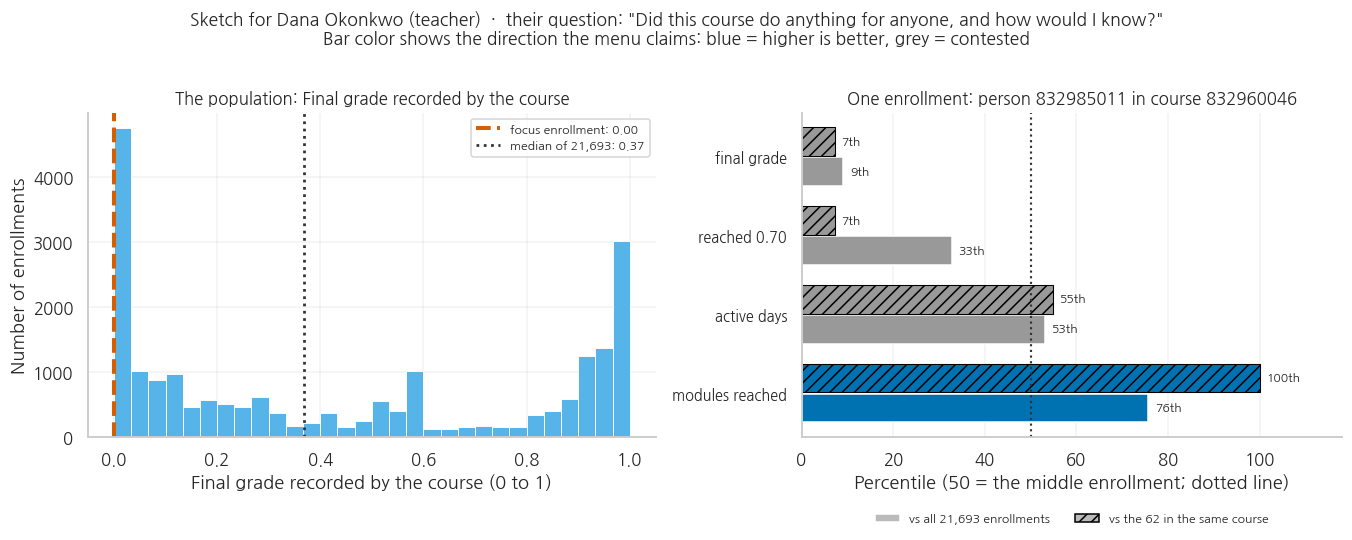

The default focus enrollment, in words:
   Registered saying "Active participant" and "I enjoy learning about topics that interest me".
   Reached 100 percent of the modules, with 5,137 recorded page views on 6 distinct days.
   0 of the 436 registrations in that course have a higher recorded page-view count.
   Rows at 100 percent of the modules, among the 64 in that course with a
   modules-reached number: 1.
   The course also recorded that they completed 75 percent of the required items.
   Their final grade is 0.00. The median final grade among the 62 enrollments in that
   course with all four measures recorded is 1.00.



How differently do these courses grade? Of the 66 courses here with at least 30 such
enrollments, 17 have a median final grade at or below 0.10 and 7 have a median at or
above 0.95. That is the spread the across-course percentile bar is averaging over.


In [11]:
DIRECTION_COLOR = {'higher is better': BLUE, 'lower is better': ORANGE, 'contested': GREY}

pct_all = core[METRIC_KEYS].rank(pct=True) * 100
pct_course = core.groupby('course_id_DI')[METRIC_KEYS].rank(pct=True) * 100


def sketch_view(persona_key, metrics, focus_idx):
    '''Two-panel mock of what this persona would see.'''
    p = PERSONAS[persona_key]
    head = metrics[0]
    r = core.loc[focus_idx]
    same_course = core[core['course_id_DI'] == r['course_id_DI']]

    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2),
                             gridspec_kw={'width_ratios': [1.05, 1.0]})

    # ---- Panel 1: the population distribution of the headline metric
    ax = axes[0]
    vals = core[head]
    heavy = head in ('nevents', 'events_per_day')
    if heavy:
        bins = np.logspace(np.log10(max(vals.min(), 0.05)), np.log10(vals.max()), 40)
        ax.set_xscale('log')
    else:
        bins = 30
    ax.hist(vals, bins=bins, color=SKY, edgecolor='white', linewidth=0.6)
    ax.axvline(float(r[head]), color=VERM, linewidth=2.6, linestyle='--',
               label='focus enrollment: {:,.2f}'.format(r[head]))
    ax.axvline(float(vals.median()), color='#333333', linewidth=1.8, linestyle=':',
               label='median of {:,}: {:,.2f}'.format(len(core), vals.median()))
    ax.set_xlabel('{} ({}){}'.format(CATALOG.loc[head, 'label'], CATALOG.loc[head, 'unit'],
                                     ', log scale' if heavy else ''))
    ax.set_ylabel('Number of enrollments')
    ax.set_title('The population: {}'.format(CATALOG.loc[head, 'label']), fontsize=11)
    ax.legend(fontsize=8, loc='upper right' if not heavy else 'upper left')

    # ---- Panel 2: percentile profile, twice
    ax = axes[1]
    labels = [CATALOG.loc[m, 'short'] for m in metrics]
    y = np.arange(len(metrics))
    v_all = [float(pct_all.loc[focus_idx, m]) for m in metrics]
    v_crs = [float(pct_course.loc[focus_idx, m]) for m in metrics]
    cols = [DIRECTION_COLOR[CATALOG.loc[m, 'direction']] for m in metrics]
    ax.barh(y + 0.19, v_all, height=0.36, color=cols, edgecolor='white')
    ax.barh(y - 0.19, v_crs, height=0.36, color=cols, edgecolor='black', hatch='///',
            linewidth=0.7)
    for yy, v in zip(y + 0.19, v_all):
        ax.text(v + 1.5, yy, '{:.0f}th'.format(v), va='center', fontsize=8)
    for yy, v in zip(y - 0.19, v_crs):
        ax.text(v + 1.5, yy, '{:.0f}th'.format(v), va='center', fontsize=8)
    ax.axvline(50, color='#333333', linewidth=1.4, linestyle=':')
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.invert_yaxis()
    ax.set_xlim(0, 118)
    ax.set_xlabel('Percentile (50 = the middle enrollment; dotted line)')
    ax.set_ylabel('')
    ax.set_title('One enrollment: person {} in course {}'.format(r['userid_DI'], r['course_id_DI']),
                 fontsize=11)
    proxies = [plt.Rectangle((0, 0), 1, 1, facecolor='#BBBBBB', edgecolor='white'),
               plt.Rectangle((0, 0), 1, 1, facecolor='#BBBBBB', edgecolor='black', hatch='///')]
    ax.legend(proxies, ['vs all {:,} enrollments'.format(len(core)),
                        'vs the {} in the same course'.format(len(same_course))],
              fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2,
              frameon=False)
    ax.grid(axis='y', alpha=0)

    fig.subplots_adjust(bottom=0.24)
    fig.suptitle('Sketch for {} ({})  ·  their question: "{}"\n'
                 'Bar color shows the direction the menu claims: blue = higher is better, '
                 'grey = contested'.format(p['name'], persona_key, p['question']),
                 fontsize=11.5, y=1.02)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    return fig


sketch_view(MY_PERSONA, MY_METRICS, FOCUS)
plt.show()

r = core.loc[FOCUS]
print('The default focus enrollment, in words:')
print('   Registered saying "{}" and "{}".'.format(r['learner_type'], r['primary_reason']))
crs_all = pc[pc['course_id_DI'] == r['course_id_DI']]
crs_core = core[core['course_id_DI'] == r['course_id_DI']]
print('   Reached {:.0f} percent of the modules, with {:,.0f} recorded page views on {:.0f} distinct days.'
      .format(r['ncontent'], r['nevents'], r['ndays_act']))
n_higher = int((crs_all['nevents'] > r['nevents']).sum())
n_full = int((crs_all['ncontent'] == 100).sum())
print('   {:,} of the {:,} registrations in that course have a higher recorded page-view count.'
      .format(n_higher, len(crs_all)))
print('   Rows at 100 percent of the modules, among the {} in that course with a'
      .format(int(crs_all['ncontent'].notna().sum())))
print('   modules-reached number: {}.'.format(n_full))
print('   The course also recorded that they completed {:.0f} percent of the required items.'
      .format(r['completed_%'] * 100))
print('   Their final grade is {:.2f}. The median final grade among the {} enrollments in that'
      .format(r['grade'], len(crs_core)))
print('   course with all four measures recorded is {:.2f}.'.format(crs_core['grade'].median()))
print()
spread = core.groupby('course_id_DI')['grade'].agg(['median', 'size'])
spread = spread[spread['size'] >= 30]
print('How differently do these courses grade? Of the {} courses here with at least 30 such'
      .format(len(spread)))
print('enrollments, {} have a median final grade at or below 0.10 and {} have a median at or'
      .format(int((spread['median'] <= 0.10).sum()), int((spread['median'] >= 0.95).sum())))
print('above 0.95. That is the spread the across-course percentile bar is averaging over.')

**Let's look at the output.** One question for the right panel, answered in a sentence: *what would
your persona do on Monday because of this?* If the sentence is "keep an eye on them", the sketch has
not yet given them anything, because keeping an eye on someone is not something your persona can do
on Monday.

Then the default focus enrollment, if you kept it. This person said at registration that they
intended to do the assignments. The file records them at 100 percent of the course modules, and the
course recorded more page views for this enrollment than for any other. The course's own
`completed_%` column says they completed three quarters of the required items, which the data
dictionary defines over the items a course explicitly requires rather than over its modules (Canvas
Network, 2016). Their grade is 0.00, and the median final grade among the 62 enrollments in that
course with all four measures recorded is a perfect 1.00.

It may help to keep three things separate:

| | |
|---|---|
| **What the data directly show** | This enrollment has `ncontent` = 100, the highest `nevents` of the 436 registrations in its course, `completed_%` = 0.75, and `grade` = 0.00, in a course whose median grade among the 62 comparable enrollments is 1.00 |
| **A plausible interpretation** | The 0.00 may record work submitted and scored zero, or nothing gradeable ever submitted, or assessments this person read past and skipped |
| **What this file cannot establish** | Which of those it is, since the file holds no record of submissions, deadlines, or anything about this person's circumstances |

Three questions before anything about the person becomes a candidate explanation:

1. **The instrument.** A grade exists only where a course has enough scored activities to compute
   one, and this file never says whether a 0.00 means "submitted and scored zero" or "never
   submitted anything gradeable". Those are different events and the column cannot tell them apart.
   The data dictionary calls this column an estimated or actual final grade, so a third reading is
   that the number was computed by the platform rather than recorded from submitted work (Canvas
   Network, 2016).
2. **The setting.** A free 16-day course. The file records nothing about what the course asked of
   anyone or what skipping an assignment meant in it.
3. **The circumstances.** They said they expected to spend one to two hours a week. The file records
   nothing else about their life.

Which of the four personas would have placed this enrollment at the bottom of its screen at the end
of the course, and what would their dashboard have called them?

## 5. The leaderboards

Each of our four people has a measure they would defensibly reach for. The course team wants to know
who met the standard it set. The platform wants to know who used the platform. The funder wants to
know who kept coming back. The learner wants to know how much of the course he got to.

So: the **top 500 enrollments by each measure**, four lists, and how much they have in common.

It may be worth writing down a guess before we look.

We get there in four steps, because the first answer is wrong in an instructive way.

### Step 1: the answer a dashboard would give

The obvious move is to sort the whole file by each measure and take the top 500, which is literally
what a leaderboard query does. **Run the cell below** to do exactly that, on all 325,199 rows.

In [12]:
from itertools import combinations

K = 500

naive = {}
for m in FOUR:
    naive[m] = set(pc[m].dropna().nlargest(K).index)

print('Top {} enrollments by each measure, taken from the whole file:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    print('   {:<10} x {:<10}  share {:>3} of {}'.format(a, b, len(naive[a] & naive[b]), K))
print()
print('The two lists the course team and the platform would each call "our best learners"')
print('have {} enrollments in common.'.format(len(naive['grade'] & naive['nevents'])))

Top 500 enrollments by each measure, taken from the whole file:

   grade      x nevents     share   0 of 500
   grade      x ndays_act   share   0 of 500
   grade      x ncontent    share  15 of 500
   nevents    x ndays_act   share 103 of 500
   nevents    x ncontent    share   0 of 500
   ndays_act  x ncontent    share   3 of 500

The two lists the course team and the platform would each call "our best learners"
have 0 enrollments in common.


### Step 2: rule out the ordinary explanation first

A result that extreme is a reason to check the code and the file before reporting it.

The first thing to check is whether the enrollments on one list are even **eligible** for the other,
which is not a fact about learners. `grade` is recorded on a quarter of the file and `nevents` on
another quarter, and nothing guarantees those are the same quarter. If the top 500 by grade mostly
have no page-view number at all, they cannot appear on the page-view list whatever they did.

**Run the cell below.**

In [13]:
print('Of the top {} by each measure, how many are even eligible for the other list?'.format(K))
print()
for a, b in [('grade', 'nevents'), ('grade', 'ndays_act'),
             ('nevents', 'grade'), ('ndays_act', 'grade')]:
    n_ok = int(pc.loc[list(naive[a]), b].notna().sum())
    print('   top {} by {:<10}: {:>3} of {} have {:<10} recorded at all'.format(K, a, n_ok, K, b))
print()
print('Most of the top-grade enrollments have no page-view number in this file,')
print('so most of them were never candidates. The zero in step 1 is mostly the file being')
print('silent, not a fact about anybody. Reporting it as a finding would have been wrong.')

Of the top 500 by each measure, how many are even eligible for the other list?

   top 500 by grade     : 165 of 500 have nevents    recorded at all
   top 500 by grade     : 168 of 500 have ndays_act  recorded at all
   top 500 by nevents   : 393 of 500 have grade      recorded at all
   top 500 by ndays_act : 454 of 500 have grade      recorded at all

Most of the top-grade enrollments have no page-view number in this file,
so most of them were never candidates. The zero in step 1 is mostly the file being
silent, not a fact about anybody. Reporting it as a finding would have been wrong.


### Step 3: ask the question again, properly

The question is the same, and now the population is the common one. Every enrollment here has all four
measures recorded, so every enrollment is eligible for all four lists.

Two more things go with the answer.

**One chance baseline is not enough.** Two unrelated lists of 500 drawn from the same 21,693
enrollments still overlap a little, just by arithmetic, and we simulate that rather than assert it. But
these lists are not uniform draws from 21,693 enrollments: each one leans heavily on a handful of
courses, which is what step 4 is about. Two lists that lean on the same big course will overlap more
than the uniform number even if, inside every course, they pick people at random and independently of
each other. So we also compute a **course-matched** baseline that holds each list's course
composition fixed and shuffles only who inside each course. That is the number to read the overlaps
against.

**A tie-break we can defend.** Section 3 showed thousands of enrollments tied at the top of `grade`
and `ncontent`. A single "top 500" on those measures is one arbitrary draw from a much larger tied
group. So we take the top 500 **two hundred times**, breaking ties at random each time, and report
the median and the range. If the answer moves around a lot across tie-breaks, what we are looking at
is the sort order rather than the measure.

**Run the cell below.** It takes several seconds, because of the two hundred draws.

In [14]:
def top_set(series, k=K, rng=None):
    '''Top k row labels of a series, with ties broken at random.'''
    jitter = pd.Series(rng.random(len(series)), index=series.index)
    ordered = pd.DataFrame({'v': series, 'j': jitter}).sort_values(
        ['v', 'j'], ascending=[False, False])
    return set(ordered.index[:k])


# --- the chance baseline, by simulation ---
rng = np.random.default_rng(8100)
N = len(core)
chance = []
for _ in range(2000):
    a = set(rng.choice(N, K, replace=False))
    b = set(rng.choice(N, K, replace=False))
    chance.append(len(a & b))
chance = np.array(chance)
CHANCE_MED = float(np.median(chance))
CHANCE_LO, CHANCE_HI = np.percentile(chance, [2.5, 97.5])
print('Chance baseline: two unrelated lists of {} drawn from {:,} enrollments'.format(K, N))
print('   overlap of {:.0f} on average, and between {:.0f} and {:.0f} in 95 percent of draws.'
      .format(chance.mean(), CHANCE_LO, CHANCE_HI))
print('   (The arithmetic answer is {} x {} / {:,} = {:.1f}, which matches.)'.format(
    K, K, N, K * K / N))
print()


# --- the second baseline, the one that knows rows sit inside courses ---
COURSE_SIZE = core['course_id_DI'].value_counts()


def course_matched_chance(set_a, set_b):
    '''Expected overlap if, WITHIN each course, the two lists picked independently.

    Each top-500 list draws unevenly across courses, and that unevenness belongs
    to the courses rather than to any agreement between the measures. Holding it
    fixed, the expected overlap is the sum over courses of
    (rows A took there) x (rows B took there) / (rows available there).
    Overlap above this number is not accounted for by course composition alone.
    '''
    a = core.loc[list(set_a), 'course_id_DI'].value_counts()
    b = core.loc[list(set_b), 'course_id_DI'].value_counts()
    return float(sum(a[c] * b[c] / COURSE_SIZE[c] for c in a.index.intersection(b.index)))


def overlap_matrix(frame, cols, B=200, seed=8100):
    '''Median overlap of top-K lists across B random tie-breaks, a 95 percent range,
    and the course-matched chance baseline for each pair.'''
    r = np.random.default_rng(seed)
    draws = {p: [] for p in combinations(cols, 2)}
    matched = {p: [] for p in combinations(cols, 2)}
    for _ in range(B):
        sets = {c: top_set(frame[c], rng=r) for c in cols}
        for a, b in combinations(cols, 2):
            draws[(a, b)].append(len(sets[a] & sets[b]))
            matched[(a, b)].append(course_matched_chance(sets[a], sets[b]))
    med = pd.DataFrame(np.nan, index=cols, columns=cols)
    rng_lo = pd.DataFrame(np.nan, index=cols, columns=cols)
    rng_hi = pd.DataFrame(np.nan, index=cols, columns=cols)
    mch = pd.DataFrame(np.nan, index=cols, columns=cols)
    for (a, b), v in draws.items():
        v = np.array(v)
        w = np.array(matched[(a, b)])
        for x, y in [(a, b), (b, a)]:
            med.loc[x, y] = np.median(v)
            rng_lo.loc[x, y] = np.percentile(v, 2.5)
            rng_hi.loc[x, y] = np.percentile(v, 97.5)
            mch.loc[x, y] = np.median(w)
    for c in cols:
        med.loc[c, c] = K
    return med, rng_lo, rng_hi, mch


med_raw, lo_raw, hi_raw, mch_raw = overlap_matrix(core, FOUR)
print('Overlap of the top {} lists, common population, median over 200 random tie-breaks:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    print('   {:<10} x {:<10}  {:>5.0f}   (95% across tie-breaks {:.0f} to {:.0f})   '
          'uniform chance {:.0f}   course-matched chance {:.0f}'
          .format(a, b, med_raw.loc[a, b], lo_raw.loc[a, b], hi_raw.loc[a, b],
                  CHANCE_MED, mch_raw.loc[a, b]))
print()
print('The last column is the one to read, rather than the one before it. The uniform 11 is the same for every')
print('row and it is the wrong yardstick: page views and active days overlap 133 against a')
print('course-matched expectation of about {:.0f}, because both lists come mostly from the'
      .format(mch_raw.loc['nevents', 'ndays_act']))
print('same enormous course. That is the confound step 4 is about, arriving early.')

Chance baseline: two unrelated lists of 500 drawn from 21,693 enrollments
   overlap of 11 on average, and between 5 and 18 in 95 percent of draws.
   (The arithmetic answer is 500 x 500 / 21,693 = 11.5, which matches.)



Overlap of the top 500 lists, common population, median over 200 random tie-breaks:

   grade      x nevents        19   (95% across tie-breaks 13 to 26)   uniform chance 11   course-matched chance 11
   grade      x ndays_act      26   (95% across tie-breaks 19 to 35)   uniform chance 11   course-matched chance 13
   grade      x ncontent       14   (95% across tie-breaks 8 to 22)   uniform chance 11   course-matched chance 13
   nevents    x ndays_act     133   (95% across tie-breaks 131 to 135)   uniform chance 11   course-matched chance 43
   nevents    x ncontent       18   (95% across tie-breaks 11 to 26)   uniform chance 11   course-matched chance 14
   ndays_act  x ncontent       17   (95% across tie-breaks 11 to 25)   uniform chance 11   course-matched chance 12

The last column is the one to read, rather than the one before it. The uniform 11 is the same for every
row and it is the wrong yardstick: page views and active days overlap 133 against a
course-matched expectation of

### Step 4: one more ordinary explanation to rule out

One pair in that table stands out. Page views and active days agree with each other far more than
either agrees with anything else, which is not surprising: they are both counts of the same clicking,
counted two ways.

A second ordinary explanation is still open, and it is the one this course has returned to since week
5. **These rows are not independent.** Every enrollment sits inside a course, and courses differ
enormously in how long they run, how much they contain, and how they grade. A leaderboard built across
156 courses might in part be a list of *courses*.

The table below is one tie-break rather than a summary of many. Page views and active days have
almost no ties at the cut, so their rows barely move from draw to draw. Thousands of enrollments
sit tied at the top of grade and of modules reached, so those two rows move by tens depending on
which tied enrollments the draw happens to take.

**Run the cell below** to check it.

In [15]:
r = np.random.default_rng(4242)
print('Where do the top {} on each list actually come from?'.format(K))
print()
conc = {}
for m in FOUR:
    t = list(top_set(core[m], rng=r))
    sub = core.loc[t]
    vc = sub['course_id_DI'].value_counts()
    conc[m] = vc
    print('   {:<10} spans {:>3} courses | biggest single course {} contributes {:>3} of {} ({:.0f}%)'
          ' | {} distinct people'.format(m, sub['course_id_DI'].nunique(), vc.index[0], vc.iloc[0], K,
                                         100 * vc.iloc[0] / K, sub['userid_DI'].nunique()))
print()
big = conc['ndays_act'].index[0]
crs = core[core['course_id_DI'] == big]
print('The course supplying most of the active-days list is {}: {}, {} days long,'.format(
    big, crs['discipline'].iloc[0], crs['course_length'].iloc[0]))
print('with {:,} enrollments in the common population and a median of {:.0f} active days,'.format(
    len(crs), crs['ndays_act'].median()))
print('against a median of {:.0f} across the whole common population.'.format(core['ndays_act'].median()))
print()
print('So the funder\'s leaderboard is, to a first approximation, one course.')
print('That is a fact about a course.')

Where do the top 500 on each list actually come from?

   grade      spans  40 courses | biggest single course 832960083 contributes 105 of 500 (21%) | 490 distinct people
   nevents    spans  30 courses | biggest single course 832960975 contributes 339 of 500 (68%) | 492 distinct people
   ndays_act  spans  28 courses | biggest single course 832960975 contributes 416 of 500 (83%) | 499 distinct people
   ncontent   spans  56 courses | biggest single course 832960975 contributes  79 of 500 (16%) | 493 distinct people

The course supplying most of the active-days list is 832960975: Humanities, 63 days long,
with 3,358 enrollments in the common population and a median of 21 active days,
against a median of 5 across the whole common population.

So the funder's leaderboard is, to a first approximation, one course.
That is a fact about a course.


### Holding the course constant

One repair is to rank people **within their own course** and then take the top 500 by within-course
standing. Now a person at the top of a short course with many enrollments is ranked on the same
basis as a person at the top of a long one, and the leaderboard is no longer a disguised list of
courses.

If the four measures still disagree after this, the disagreement is about the measures.

**Run the two cells below.**

In [16]:
FOUR_CP = [m + '_in_course' for m in FOUR]
for m in FOUR:
    core[m + '_in_course'] = core.groupby('course_id_DI')[m].rank(pct=True)

med_cp, lo_cp, hi_cp, mch_cp = overlap_matrix(core, FOUR_CP, seed=99)

print('Same four measures, ranked within each course. Overlap of the top {} lists:'.format(K))
print()
for a, b in combinations(FOUR, 2):
    ac, bc = a + '_in_course', b + '_in_course'
    print('   {:<10} x {:<10}  {:>5.0f} of {}  ({:.0f}% agreement)   '
          'uniform chance {:.0f}   course-matched chance {:.0f}'
          .format(a, b, med_cp.loc[ac, bc], K, 100 * med_cp.loc[ac, bc] / K,
                  CHANCE_MED, mch_cp.loc[ac, bc]))
print()
r2 = np.random.default_rng(7)
for m in FOUR_CP:
    sub = core.loc[list(top_set(core[m], rng=r2))]
    print('   {:<22} now spans {:>3} courses, biggest contributes {:>3}'.format(
        m, sub['course_id_DI'].nunique(), sub['course_id_DI'].value_counts().iloc[0]))
print()
gn = med_cp.loc['grade_in_course', 'nevents_in_course']
gn_chance = mch_cp.loc['grade_in_course', 'nevents_in_course']
print('The headline, stated carefully:')
print('   Holding the course constant, the top {} by grade and the top {} by page views'.format(K, K))
print('   share {:.0f} enrollments. Against the uniform baseline that looks like {:.0f} times'.format(
    gn, gn / CHANCE_MED))
print('   chance, and that is the wrong comparison: these two lists both concentrate in the')
print('   same courses, so the course-matched baseline is about {:.0f}, and the overlap is'.format(
    gn_chance))
print('   only about {:.1f} times what course composition alone would produce.'.format(gn / gn_chance))
print('   So the lists overlap more than course composition alone would produce, by less than')
print('   the uniform number suggests, and')
print('   {:.0f} of the {} enrollments on one list, which is {:.0f} percent of them, are not on'.format(
    K - gn, K, 100 * (K - gn) / K))
print('   the other.')

Same four measures, ranked within each course. Overlap of the top 500 lists:

   grade      x nevents        82 of 500  (16% agreement)   uniform chance 11   course-matched chance 45
   grade      x ndays_act      82 of 500  (16% agreement)   uniform chance 11   course-matched chance 42
   grade      x ncontent       70 of 500  (14% agreement)   uniform chance 11   course-matched chance 46
   nevents    x ndays_act     145 of 500  (29% agreement)   uniform chance 11   course-matched chance 43
   nevents    x ncontent      101 of 500  (20% agreement)   uniform chance 11   course-matched chance 45
   ndays_act  x ncontent       65 of 500  (13% agreement)   uniform chance 11   course-matched chance 42

   grade_in_course        now spans 122 courses, biggest contributes  46
   nevents_in_course      now spans 155 courses, biggest contributes  60
   ndays_act_in_course    now spans 146 courses, biggest contributes  59
   ncontent_in_course     now spans  90 courses, biggest contributes  95

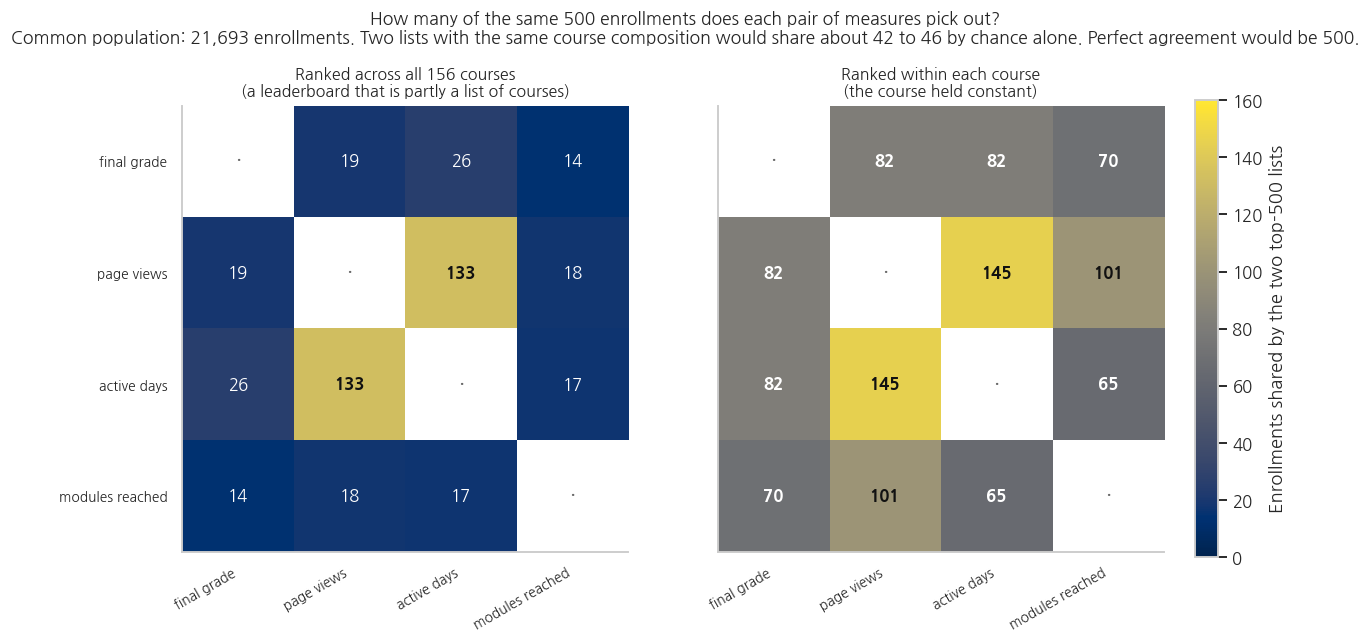

In [17]:
def draw_overlap(ax, mat, cols, labels, title):
    z = mat.loc[cols, cols].values.astype(float)
    shown = np.where(np.eye(len(cols), dtype=bool), np.nan, z)
    im = ax.imshow(shown, cmap='cividis', vmin=0, vmax=160)
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                ax.text(j, i, '·', ha='center', va='center', color='#666666', fontsize=14)
            else:
                v = z[i, j]
                ax.text(j, i, '{:.0f}'.format(v), ha='center', va='center', fontsize=11,
                        color='white' if v < 95 else '#111111',
                        fontweight='bold' if v > 60 else 'normal')
    ax.set_title(title, fontsize=10.5)
    ax.grid(False)
    return im


short = [CATALOG.loc[m, 'short'] for m in FOUR]
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.4))
im = draw_overlap(axes[0], med_raw, FOUR, short,
                  'Ranked across all {} courses\n(a leaderboard that is partly a list of courses)'
                  .format(core['course_id_DI'].nunique()))
draw_overlap(axes[1], med_cp, FOUR_CP, short,
             'Ranked within each course\n(the course held constant)')
axes[1].set_yticklabels([])
cb = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03)
cb.set_label('Enrollments shared by the two top-500 lists')
fig.suptitle('How many of the same 500 enrollments does each pair of measures pick out?\n'
             'Common population: {:,} enrollments. Two lists with the same course composition '
             'would share about {:.0f} to {:.0f} by chance alone. Perfect agreement would be 500.'
             .format(len(core), np.nanmin(mch_cp.values), np.nanmax(mch_cp.values)),
             fontsize=11.5, y=1.03)
plt.show()

**Let's look at the output.** The two panels sit side by side, and the right-hand one is the
comparison that holds the course constant. It may help to read it against the course-matched baseline
rather than against the uniform 11: once course composition is held fixed, chance alone would put
roughly 42 to 46 enrollments on both lists.

So each pair overlaps more than course composition alone would produce, by factors of 1.5 to 3.4,
where the uniform baseline would have made the same overlaps look like six to thirteen times chance.
These measures are not measuring unrelated things and they are not measuring the same thing either.

The closest any pair comes to agreement is 145 of 500, the two clicking measures agreeing with each
other, which mostly says that those two are close to a single measure. Every pair involving the
grade sits at 82 or below, so at least four in five of the enrollments on one list are absent from
the other. It is worth noticing how much work the baseline did: on the uniform number, 65 of 500
looks like six times chance and therefore like strong agreement, while against the course-matched
baseline it is not far above what course composition produces on its own.

The design question follows. A dashboard shows a top or a bottom rather than the middle, and it is
at the ends that these measures stop agreeing.

**Let's discuss**, with the persona cards in view:

1. Each of the four personas would leave with a different list of people to celebrate, and each list
   is defensible. Which one tends to get built in practice, and what makes it the one?
2. The left panel is what we would have had without checking the nesting. What might someone have
   concluded from it, and what might that have cost the people on the lists?
3. Nobody in this file was told which measure would be used. Does that change your answer to
   question 1?

### One more check, because the obvious objection is a good one

Someone will reasonably say: surely these measures just correlate, and the top-500 business is a trick
of looking at a narrow slice. That is half right, and the cell below shows the other half.

We report two correlation coefficients, because one would be misleading here. `nevents` runs from 1 to
530,411 and is heavily right-skewed, so a Pearson correlation on the raw counts is dominated by a
handful of enormous values. Spearman uses the ranks instead, which is the more informative summary for
data shaped like this.

**Run the cell below.**

In [18]:
sp = core[FOUR].corr(method='spearman')
pe = core[FOUR].corr(method='pearson')
print('Spearman (rank) correlations, common population, n = {:,}'.format(len(core)))
print(sp.round(3).to_string())
print()
print('Pearson (raw value) correlations, for contrast:')
print(pe.round(3).to_string())
print()
print('Grade against page views: Spearman {:.2f}, Pearson {:.2f}.'.format(
    sp.loc['grade', 'nevents'], pe.loc['grade', 'nevents']))
print('The gap is the skew. Page views here run from {:,.0f} to {:,.0f}, against a median of {:,.0f}.'
      .format(core['nevents'].min(), core['nevents'].max(), core['nevents'].median()))
print()
print('So the objection is half right and the half it gets wrong is the important half:')
print('these measures agree moderately in the broad middle and hardly at all at the top.')
print('A rank correlation of {:.2f} sounds like agreement. It coexists with two top-500 lists'.format(
    sp.loc['grade', 'nevents']))
print('that share {:.0f} of 500 once you hold the course constant. Both are true at once, and'.format(
    med_cp.loc['grade_in_course', 'nevents_in_course']))
print('a dashboard lives at the end of the distribution where the agreement has run out.')

Spearman (rank) correlations, common population, n = 21,693
           grade  nevents  ndays_act  ncontent
grade      1.000    0.514      0.557     0.373
nevents    0.514    1.000      0.552     0.477
ndays_act  0.557    0.552      1.000     0.223
ncontent   0.373    0.477      0.223     1.000

Pearson (raw value) correlations, for contrast:
           grade  nevents  ndays_act  ncontent
grade      1.000    0.175      0.514     0.344
nevents    0.175    1.000      0.322     0.134
ndays_act  0.514    0.322      1.000     0.186
ncontent   0.344    0.134      0.186     1.000

Grade against page views: Spearman 0.51, Pearson 0.17.
The gap is the skew. Page views here run from 1 to 530,411, against a median of 330.

So the objection is half right and the half it gets wrong is the important half:
these measures agree moderately in the broad middle and hardly at all at the top.
A rank correlation of 0.51 sounds like agreement. It coexists with two top-500 lists
that share 82 of 500 once you h

**Let's discuss.** "The measures correlate, so it does not matter much which one I pick" is the
objection this section answers. Moderate correlation across a whole population is compatible with
almost complete disagreement about who is at the top.

Please write the two-sentence version you would say to a colleague who has just said that sentence to
you. The first sentence agrees with them, and the second says what the agreement leaves out.

## 6. The swap: read your own sketch as another persona

You built something for one person. Now it gets read back as one of the others.

The next cell does the mechanical part: it takes your metric set and reports, for each of the other
three personas, what they could do with each metric and which of their stated fears it touches. The
mechanical part is only a prompt.

**Run the two cells below.**

In [19]:
def critique(metrics, designed_for, viewer):
    p, v = PERSONAS[designed_for], PERSONAS[viewer]
    words = {0: 'CANNOT ACT on this', 1: 'can act, but only after a conversation',
             2: 'CAN ACT directly'}
    print('-' * 86)
    print('{} ({}) reads a view built for {} ({})'.format(
        v['name'], viewer, p['name'], designed_for))
    print('   They arrive asking: "{}"   (grain they need: {})'.format(v['question'], v['grain']))
    print('   Access reality: {}'.format(v['access_reality']))
    print()
    dead, scary = 0, []
    for m in metrics:
        rowc = CATALOG.loc[m]
        score = int(rowc['act_' + viewer])
        flagged = viewer in str(rowc['fears']).split(',')
        dead += (score == 0)
        if flagged:
            scary.append(rowc['label'])
        print('   {:<40} {}{}'.format(rowc['label'], words[score],
                                      '   <-- touches a stated fear' if flagged else ''))
        print('   {:<40} often mistaken for: {}'.format('', rowc['mistaken_for']))
    print()
    print('   Verdict: {} of {} metrics are inert for this person.'.format(dead, len(metrics)))
    if scary:
        print('   Touches their fears: ' + '; '.join(scary))
    if v['grain'] != p['grain']:
        print("   Grain mismatch: this view thinks in '{}', they need '{}'.".format(
            p['grain'], v['grain']))


for other in [k for k in PERSONA_ORDER if k != MY_PERSONA]:
    critique(MY_METRICS, MY_PERSONA, other)
print('-' * 86)

--------------------------------------------------------------------------------------
Malik Ferrer (learner) reads a view built for Dana Okonkwo (teacher)
   They arrive asking: "Did I get what I came for, and is anything here even about that?"   (grain they need: himself)
   Access reality: Sees a progress bar if the course has one. Sees none of the rest, and was never told this file would exist.

   Final grade recorded by the course       can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: how much this person learned
   Reached a grade of 0.70 or more          can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: completion, and then success
   Distinct days with any recorded activity can act, but only after a conversation   <-- touches a stated fear
                                            often mistaken for: commitment
   

Actionability: 0 = cannot act, 1 = only after a conversation, 2 = can act directly
                                       metric  teacher  learner  platform  funder touches the fear of
           Final grade recorded by the course        2        1         1       2     teacher,learner
              Reached a grade of 0.70 or more        2        1         2       2     teacher,learner
            Recorded page views in the course        1        0         2       1             learner
           Recorded page views per active day        1        1         1       0             learner
     Distinct days with any recorded activity        1        1         2       2             learner
        Percent of the course modules reached        2        2         1       1              nobody
Platform flag: documented as >=50% of modules        1        0         2       1             learner

Sum of the ordinal actionability codes per stakeholder, which orders them but is not
a count of metr

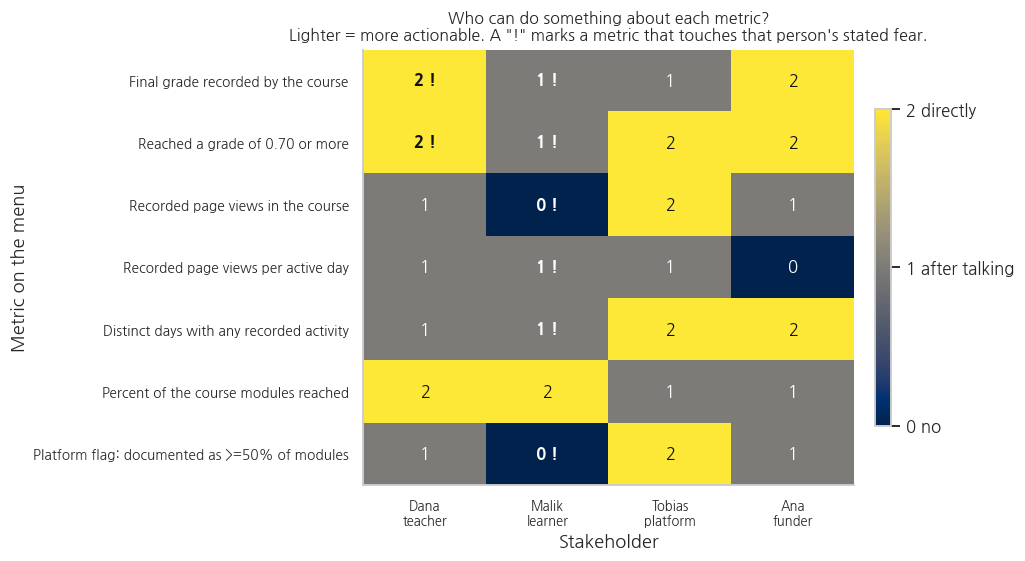

In [20]:
# The whole menu crossed with all four stakeholders, as a table and as a picture.
act = CATALOG[['act_' + k for k in PERSONA_ORDER]].copy()
act.columns = PERSONA_ORDER
tbl = act.copy()
tbl.insert(0, 'metric', CATALOG['label'])
tbl['touches the fear of'] = CATALOG['fears'].replace('', 'nobody')
print('Actionability: 0 = cannot act, 1 = only after a conversation, 2 = can act directly')
print(tbl.to_string(index=False))
print()
print('Sum of the ordinal actionability codes per stakeholder, which orders them but is not')
print('a count of metrics (max {}):'.format(2 * len(METRIC_KEYS)))
print(act.sum().to_string())

fig, ax = plt.subplots(figsize=(9.4, 5.2))
z = act.values.astype(float)
im = ax.imshow(z, cmap='cividis', vmin=0, vmax=2, aspect='auto')
ax.set_xticks(range(len(PERSONA_ORDER)))
ax.set_xticklabels(['{}\n{}'.format(PERSONAS[k]['name'].split()[0], k)
                    for k in PERSONA_ORDER], fontsize=8.5)
ax.set_yticks(range(len(METRIC_KEYS)))
ax.set_yticklabels([CATALOG.loc[m, 'label'] for m in METRIC_KEYS], fontsize=9)
for i, m in enumerate(METRIC_KEYS):
    for j, k in enumerate(PERSONA_ORDER):
        v = int(act.loc[m, k])
        mark = ' !' if k in str(CATALOG.loc[m, 'fears']).split(',') else ''
        ax.text(j, i, '{}{}'.format(v, mark), ha='center', va='center', fontsize=11,
                color='white' if v < 1.5 else '#111111', fontweight='bold' if mark else 'normal')
ax.set_xlabel('Stakeholder')
ax.set_ylabel('Metric on the menu')
ax.set_title('Who can do something about each metric?\n'
             'Lighter = more actionable. A "!" marks a metric that touches that '
             "person's stated fear.", fontsize=10.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, ticks=[0, 1, 2])
cb.ax.set_yticklabels(['0 no', '1 after talking', '2 directly'])
plt.tight_layout()
plt.show()

**Let's look at the output.** Reading down the learner's column and then the platform's: the person
every row of this file is about can act directly on one metric out of seven, and the company that owns
the file can act directly on four.

The bright cells with a `!` beside them are metrics somebody can act on *and* that touch a stated
fear. Those are the cells where a co-design conversation might change something that a default
setting would not.

*Connecting to the readings.* Bang and Vossoughi (2016) describe participatory design research as the
study and reworking of relations rather than the collection of stakeholder preferences. This figure is
one picture of a relation: who is measured, and who holds the measurement. It may be worth asking what
relation your own sketch reproduces, and what would have to change for it to reproduce a different
one.

### What the learners said at registration

In most learning analytics files the learner persona has to be imagined.

That is not so here. At registration Canvas Network asked people **what kind of participant they
expected to be**, and 35,110 enrollments answered. So when a group builds a completion dashboard and
then swaps into the learner's chair, the file records answers from people the dashboard would be
about.

**What this variable records, and what it does not.** `learner_type` holds one answer to one menu of
options, chosen once, at registration or at the start of the course (Canvas Network, 2016). It is
not a stable property of anyone. The four groups are also very different in size, from 16,169
enrollments down to 2,539, and the survey covers about a tenth of the file. What follows is an
exercise in reading a recorded group difference carefully rather than a finding about any of the
four groups.

Two questions, in order:

1. If you put a completion bar on a screen, how many people does it mark as a "failure"? The word is
   the dashboard's, not ours, and the point of the exercise is to see how many people it fits.
2. How many of them said in advance that they were not trying to complete?

**Run the four cells below.**

In [21]:
BAR = 0.70

graded = pc['grade'].notna()
n_pass = int((pc['grade'] >= BAR).sum())
print('Question 1: who does a completion bar call a failure?')
print()
print('   Enrollments with a grade recorded at all : {:,}'.format(int(graded.sum())))
print('   Of those, {:,} reached {:.0%} or more   : {:.1f} percent'.format(
    n_pass, BAR, 100 * n_pass / graded.sum()))
print('   As a share of all {:,} rows in the file  : {:.1f} percent'.format(
    len(pc), 100 * n_pass / len(pc)))
print()
print('   A dashboard drawing its denominator from registrations would report a')
print('   {:.1f} percent completion rate and color {:.1f} percent of the file red.'.format(
    100 * n_pass / len(pc), 100 - 100 * n_pass / len(pc)))
print('   Which denominator gets used is a design decision, and it moves the headline')
print('   number by a factor of four.')
print()

not_doing = survey['plan'].isin(['Passive participant', 'Drop-in', 'Observer'])
print('Question 2: what did they say they were going to do?')
print()
print('   Of the {:,} enrollments that answered ({:,} distinct people),'.format(
    len(survey), survey['userid_DI'].nunique()))
print('   {:,} ({:.1f} percent, {:,} distinct people) chose an answer that says'.format(
    int(not_doing.sum()), 100 * not_doing.mean(),
    survey.loc[not_doing, 'userid_DI'].nunique()))
print('   in so many words that they did not plan to do the assignments:')
print()
for lbl, n in survey.loc[not_doing, 'plan'].value_counts().items():
    print('      {:<22} {:>6,}'.format(lbl, n))
print()
print('   The remaining {:,} said they intended to take the course as a student and'.format(
    int((~not_doing).sum())))
print('   do the assignments.')

Question 1: who does a completion bar call a failure?

   Enrollments with a grade recorded at all : 82,002
   Of those, 17,515 reached 70% or more   : 21.4 percent
   As a share of all 325,199 rows in the file  : 5.4 percent

   A dashboard drawing its denominator from registrations would report a
   5.4 percent completion rate and color 94.6 percent of the file red.
   Which denominator gets used is a design decision, and it moves the headline
   number by a factor of four.

Question 2: what did they say they were going to do?

   Of the 35,110 enrollments that answered (30,336 distinct people),
   18,941 (53.9 percent, 16,978 distinct people) chose an answer that says
   in so many words that they did not plan to do the assignments:

      Passive participant    13,582
      Drop-in                 2,820
      Observer                2,539

   The remaining 16,169 said they intended to take the course as a student and
   do the assignments.


In [22]:
# Grades by declared plan, with an interval that respects the nesting.
# Rows sit inside courses, and courses differ wildly in how they grade, so the
# resampling unit is the course, not the row. This is a cluster bootstrap.
def cluster_boot_median(frame, value_col, group_col, plan_col, plans, B=400, seed=31):
    r = np.random.default_rng(seed)
    courses = frame[group_col].unique()
    banks = {}
    for pl in plans:
        sub = frame[frame[plan_col] == pl]
        banks[pl] = {c: g[value_col].dropna().to_numpy()
                     for c, g in sub.groupby(group_col)}
    out = {pl: [] for pl in plans}
    for _ in range(B):
        pick = r.choice(courses, size=len(courses), replace=True)
        for pl in plans:
            bank = banks[pl]
            parts = [bank[c] for c in pick if c in bank]
            if parts:
                out[pl].append(np.median(np.concatenate(parts)))
    return {pl: np.percentile(v, [2.5, 97.5]) for pl, v in out.items() if v}


ci = cluster_boot_median(survey, 'grade', 'course_id_DI', 'plan', PLAN_ORDER)

print('Final grade by what the person said they intended to do, at registration or at the start')
print('of the course')
print('(median, with a 95 percent interval from resampling {} courses, not rows)'.format(
    survey['course_id_DI'].nunique()))
print()
rows = []
for pl in PLAN_ORDER:
    g = survey.loc[survey['plan'] == pl, 'grade'].dropna()
    lo, hi = ci[pl]
    rows.append(dict(plan=pl, enrollments=int((survey['plan'] == pl).sum()),
                     with_a_grade=len(g), median_grade=round(g.median(), 3),
                     interval='[{:.3f}, {:.3f}]'.format(lo, hi),
                     reached_070='{:,} of {:,} = {:.1f}%'.format(
                         int((g >= BAR).sum()), len(g), 100 * (g >= BAR).mean())))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print()
print('The intervals are worth reading before the ordering. Each plan has its own median and its own')
print('interval, and no test of the difference between two plans is being run here. The interval on')
print('each plan overlaps the interval on the plan next to it, and the Active and Observer intervals')
print('do not overlap, which is a description of four estimates rather than a comparison of them.')
print('Then read the last column with the first one. {:.1f} percent of the enrollments whose'.format(
    100 * (survey.loc[survey['plan'] == 'Observer', 'grade'].dropna() >= BAR).mean()))
print('registration answer was "Observer" reached a grade of 0.70 or more. Whatever these')
print('answers are, they are not a clean sorting of people into finishers and non-finishers,')
print('and a design that treated them that way would be wrong about thousands of people.')

Final grade by what the person said they intended to do, at registration or at the start
of the course
(median, with a 95 percent interval from resampling 145 courses, not rows)

               plan  enrollments  with_a_grade  median_grade       interval             reached_070
 Active participant        16169         13355         0.175 [0.103, 0.247] 3,822 of 13,355 = 28.6%
Passive participant        13582         11156         0.083 [0.032, 0.132] 2,289 of 11,156 = 20.5%
            Drop-in         2820          2273         0.022 [0.000, 0.070]    355 of 2,273 = 15.6%
           Observer         2539          1926         0.007 [0.000, 0.047]    257 of 1,926 = 13.3%

The intervals are worth reading before the ordering. Each plan has its own median and its own
interval, and no test of the difference between two plans is being run here. The interval on
each plan overlaps the interval on the plan next to it, and the Active and Observer intervals
do not overlap, which is a description 

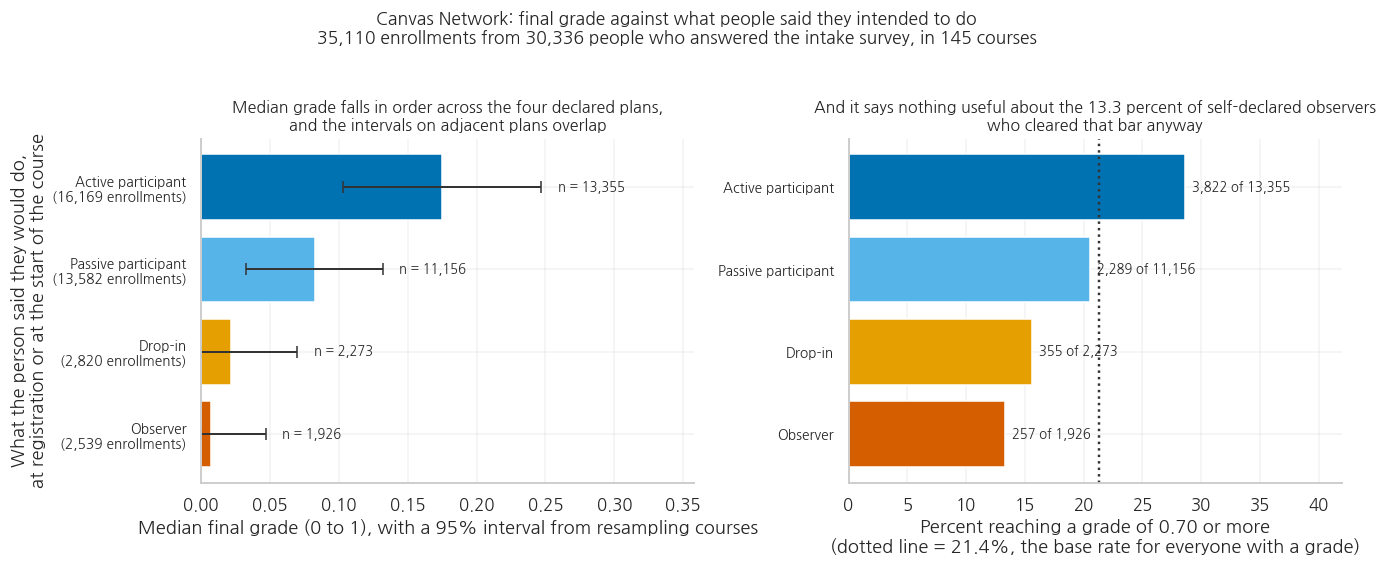

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9))

# Left: median grade by declared plan, with cluster bootstrap intervals
ax = axes[0]
meds = [survey.loc[survey['plan'] == pl, 'grade'].dropna().median() for pl in PLAN_ORDER]
los = [ci[pl][0] for pl in PLAN_ORDER]
his = [ci[pl][1] for pl in PLAN_ORDER]
err = np.array([np.array(meds) - np.array(los), np.array(his) - np.array(meds)])
cols = [BLUE, SKY, ORANGE, VERM]
y = np.arange(len(PLAN_ORDER))
ax.barh(y, meds, xerr=err, color=cols, edgecolor='white', capsize=4,
        error_kw=dict(ecolor='#333333', elinewidth=1.3))
for i, pl in enumerate(PLAN_ORDER):
    n = int(survey.loc[survey['plan'] == pl, 'grade'].notna().sum())
    ax.text(his[i] + 0.012, i, 'n = {:,}'.format(n), va='center', fontsize=8.5)
ax.set_yticks(y)
ax.set_yticklabels(['{}\n({:,} enrollments)'.format(pl, int((survey['plan'] == pl).sum()))
                    for pl in PLAN_ORDER], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(his) * 1.45)
ax.set_xlabel('Median final grade (0 to 1), with a 95% interval from resampling courses')
ax.set_ylabel('What the person said they would do,\nat registration or at the start of the course')
ax.set_title('Median grade falls in order across the four declared plans,\n'
             'and the intervals on adjacent plans overlap', fontsize=10.5)

# Right: share reaching the 70 percent bar, counts on the bars
ax = axes[1]
share = [100 * (survey.loc[survey['plan'] == pl, 'grade'].dropna() >= BAR).mean()
         for pl in PLAN_ORDER]
ax.barh(y, share, color=cols, edgecolor='white')
for i, pl in enumerate(PLAN_ORDER):
    g = survey.loc[survey['plan'] == pl, 'grade'].dropna()
    ax.text(share[i] + 0.6, i, '{:,} of {:,}'.format(int((g >= BAR).sum()), len(g)),
            va='center', fontsize=8.5)
base = 100 * (pc['grade'].dropna() >= BAR).mean()
ax.axvline(base, color='#333333', linestyle=':', linewidth=1.6)
ax.set_yticks(y)
ax.set_yticklabels(PLAN_ORDER, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 42)
ax.set_xlabel('Percent reaching a grade of 0.70 or more\n'
              '(dotted line = {:.1f}%, the base rate for everyone with a grade)'.format(base))
ax.set_ylabel('')
obs = survey.loc[survey['plan'] == 'Observer', 'grade'].dropna()
ax.set_title('And it says nothing useful about the {:.1f} percent of self-declared observers\n'
             'who cleared that bar anyway'.format(100 * (obs >= BAR).mean()), fontsize=10.5)

fig.suptitle('Canvas Network: final grade against what people said they intended to do\n'
             '{:,} enrollments from {:,} people who answered the intake survey, in {} courses'
             .format(len(survey), survey['userid_DI'].nunique(),
                     survey['course_id_DI'].nunique()), fontsize=11.5, y=1.04)
plt.tight_layout()
plt.show()

In [24]:
# And what did they say they came for?
reasons = pc['primary_reason'].dropna()
reasons = reasons[reasons != 'Missing']
top = reasons.value_counts()
print('Dropped {:,} rows whose primary_reason literally says "Missing".'.format(
    int((pc['primary_reason'] == 'Missing').sum())))
print()
print('Why people said they registered, {:,} enrollments answering:'.format(len(reasons)))
print()
for lbl, n in top.items():
    print('   {:>6,}  ({:>4.1f}%)  {}'.format(n, 100 * n / len(reasons), lbl))
print()
print('The single most common answer, given by {:,} of {:,} ({:.1f} percent), is'.format(
    top.iloc[0], len(reasons), 100 * top.iloc[0] / len(reasons)))
print('"{}".'.format(top.index[0]))
print()
print('Now look back at the menu in section 3 and find the metric that measures that.')
print('There is not one. There is no column in this file that records whether a person')
print('enjoyed learning about a topic that interested them. Look back at OULAD in weeks 2,')
print('3, 4 and 8, and at the essay corpus in week 5, and there is none there either.')
print()
print('That is the finding to carry into your Rough Draft. The measures on the menu are not')
print('there because they matter most. They are there because they were the ones a web')
print('server writes down for free.')

Dropped 1,876 rows whose primary_reason literally says "Missing".

Why people said they registered, 36,495 enrollments answering:

   20,494  (56.2%)  I enjoy learning about topics that interest me
    4,382  (12.0%)  I hope to gain skills for a new career
    2,958  ( 8.1%)  I like the format (online)
    2,319  ( 6.4%)  I am curious about MOOCs
    2,209  ( 6.1%)  I hope to gain skills for a promotion at work
    1,626  ( 4.5%)  I want to try Canvas Network
    1,294  ( 3.5%)  I enjoy being part of a community of learners
      780  ( 2.1%)  I am preparing to go back to school
      288  ( 0.8%)  I am preparing for college for the first time
      145  ( 0.4%)  I hope to gain skills to use at work

The single most common answer, given by 20,494 of 36,495 (56.2 percent), is
"I enjoy learning about topics that interest me".

Now look back at the menu in section 3 and find the metric that measures that.
There is not one. There is no column in this file that records whether a person
enjo

**Let's look at the output, and at the boundary on it.** Everything in the last three cells is about
**respondents**. 35,110 enrollments answered the learner-type question, out of 325,199 rows, which
is 10.8 percent. We have no way to know whether the other 89.2 percent would have answered the same
way, and the people who answered may differ from the people who did not in ways this file does not
record.

| | |
|---|---|
| **What the data directly show** | Of the 35,110 enrollments that answered, 18,941, or 53.9 percent, chose an answer describing not doing the assignments; median grades run 0.175, 0.083, 0.022 and 0.007 across the four declared plans, with each interval overlapping its neighbor; 13.3 percent of self-declared observers who have a grade cleared 0.70 |
| **A plausible interpretation** | What someone says at registration carries some information about what the group as a whole will do, and much less about any individual |
| **What this file cannot establish** | Whether the 89.2 percent who did not answer would have answered the same way, or what any of these people were trying to do once the course had started |

So the defensible sentence is not "most learners were not trying to complete". It is: **of the
people who answered, a majority said they were not planning to do the assignments, and a completion
dashboard would have counted every one of them as a failure.** It is the same restriction as Week
5's spans nested inside essays and Week 9's eight groups.

**Let's discuss**, for the swap:

1. Your persona's dashboard is on the screen and Malik is reading it over your shoulder. He answered
   the survey. Which sentence do you say to him first?
2. The survey is eleven years old and was answered by a tenth of the file. Would you still bring it to
   the design meeting? What would you say alongside it?
3. What would someone have had to ask at registration for the dashboard you sketched to be about the
   thing people came for? The question is one sentence, and it is rarely asked in this field.

## 7. Retroactive design audit

We have spent ten weeks building analytics artifacts about real people, on real published data, and
this notebook makes eleven. We did it the way the field usually does it: researchers deciding what to
measure, with the measured parties absent.

The next cell lists every artifact from weeks 1 through 11, names the dataset it used and the design
decision it quietly made, and asks for a score from 0 to 3 for how much voice each persona should have
had:

- `0` no legitimate stake
- `1` should have been informed
- `2` should have been consulted before it was built
- `3` should have held a veto

**The four personas appear in every week under different names.** In every one of these datasets there
was somebody who built the learning experience (the *teacher* column), somebody it was for (the
*learner* column), an institution or company whose system did the recording (the *platform* column),
and somebody who paid for or commissioned the work (the *funder* column). The names change, the four
positions do not.

The dictionary comes pre-filled with my first guess, and it is worth revising. Changing numbers and
re-running is the exercise, and one moved cell with a reason behind it is plenty to bring to the
discussion.

Two nuances are worth catching.

Week 10 used a science game played by children, and Week 6 used the JUSThink corpus, which records
78 children in 39 teams working with a robot. The four persona labels carry very different weight
when the learner is a child and a guardian is not one of the four columns. That absence is a
finding, and it is what the first task under Going further exists for.

The wording of the descriptions is also part of what is being audited. Where a week used one of the
field's deficit-coded terms, the description quotes it rather than repeats it, because **which words an
artifact chose is one of the design decisions being audited.** "Risk" and "hint spam" are somebody's
choice of vocabulary, and each arrived without the person it describes present.

**Run the two cells below.**

In [25]:
# Each description names the decision the artifact made, in the active voice, because the
# point of the audit is that somebody chose. Deficit-coded terms are quoted, not adopted.
ARTIFACTS = {
    'W1  first real table':
        ('UCI student performance, 395 secondary students in Portugal',
         'Chose which background columns to stand beside a final grade, and made the treatment '
         'of 38 zero grades a stated choice with the results reported both ways rather than a '
         'silent one.'),
    'W2  mapping the landscape':
        ('OULAD, module BBB, two presentations',
         'Chose recorded clicks as the thing worth counting, and reported how little of an '
         'outcome they account for.'),
    'W3  bias audit':
        ('OULAD, module BBB, and UCI student performance',
         'Named the target after a registry outcome rather than "risk", then audited whom the '
         'model flags across deprivation deciles and disability status, twice, in two countries.'),
    'W4  teacher dashboard':
        ('OULAD, module BBB',
         'Chose which panels a teacher sees first, and therefore what she never sees.'),
    'W5  text analytics':
        ('PERSUADE 2.0, four prompts',
         "Turned students' written arguments into discourse-move tags and effectiveness ratings "
         'that somebody else had scored.'),
    'W6  multimodal participation':
        ('JUSThink, children working with a robot at EPFL',
         'Defined participation out of speech seconds and interface actions, because those are '
         'the channels the study recorded.'),
    'W7  help-seeking traces':
        ('EdNet KT3, users of a commercial test-prep tutor in Korea',
         'Picked thirty minutes for what a study session is and ten seconds for what counts as '
         'reading an explanation, and quoted the field\'s "gaming the system" and "hint spam" '
         'as objects of study rather than applying either to anybody.'),
    'W8  networks and time':
        ('An edX MOOC forum, and OULAD, module BBB',
         'Chose which reply counts as a tie and who counts as a connector, built a withdrawal '
         'curve from real unregistration dates, and tested whether submitting close to a '
         'deadline goes with lower scores.'),
    'W9  collaboration':
        ('A Spanish computer-networks chat log, and the JUSThink records',
         'Scored groups on how evenly the recorded talk was shared, retired a response-time '
         'measure the platform clock could not support, and carried the measure into a second '
         'setting that has an outcome where the first has none.'),
    'W10 game analytics':
        ('Open Game Data, Field Day Lab, two games',
         'Read what children did at a hard moment in a game as a predictor of what they did '
         'next, and read six words on a mood menu as evidence about how they felt.'),
    'W11 today, this notebook':
        ('Canvas Network person-course, 325,199 enrollments',
         'Ranked enrollments four different ways and put 500 enrollments on each list, without '
         'asking one of them which measure they would have chosen.'),
}

# The numbers to change: 0 no stake, 1 inform, 2 consult, 3 veto.
#    Order is [teacher, learner, platform, funder].
AUDIT = {
    'W1  first real table':        [3, 3, 1, 0],
    'W2  mapping the landscape':   [2, 3, 2, 0],
    'W3  bias audit':              [3, 3, 2, 1],
    'W4  teacher dashboard':       [3, 2, 1, 1],
    'W5  text analytics':          [2, 3, 1, 0],
    'W6  multimodal participation': [3, 3, 1, 1],
    'W7  help-seeking traces':     [2, 3, 2, 0],
    'W8  networks and time':       [2, 3, 2, 1],
    'W9  collaboration':           [3, 3, 0, 0],
    'W10 game analytics':          [2, 3, 1, 2],
    'W11 today, this notebook':    [3, 3, 3, 1],
}

audit_df = pd.DataFrame(AUDIT, index=PERSONA_ORDER).T
audit_df.index.name = 'artifact'

print('What each artifact used, and what it decided:')
print()
for k, (dataset, decision) in ARTIFACTS.items():
    print('  {}'.format(k))
    print('     data: {}'.format(dataset))
    print('     decision: {}'.format(decision))
print()
print('Voice scores (0 none, 1 inform, 2 consult, 3 veto):')
print(audit_df.to_string())
print()
print('Sum of the ordinal voice codes per stakeholder (max {}):'.format(3 * len(AUDIT)))
print(audit_df.sum().to_string())
print()
print('Number of these artifacts built with that stakeholder present: 0, for all four.')

What each artifact used, and what it decided:

  W1  first real table
     data: UCI student performance, 395 secondary students in Portugal
     decision: Chose which background columns to stand beside a final grade, and made the treatment of 38 zero grades a stated choice with the results reported both ways rather than a silent one.
  W2  mapping the landscape
     data: OULAD, module BBB, two presentations
     decision: Chose recorded clicks as the thing worth counting, and reported how little of an outcome they account for.
  W3  bias audit
     data: OULAD, module BBB, and UCI student performance
     decision: Named the target after a registry outcome rather than "risk", then audited whom the model flags across deprivation deciles and disability status, twice, in two countries.
  W4  teacher dashboard
     data: OULAD, module BBB
     decision: Chose which panels a teacher sees first, and therefore what she never sees.
  W5  text analytics
     data: PERSUADE 2.0, four prompts
 

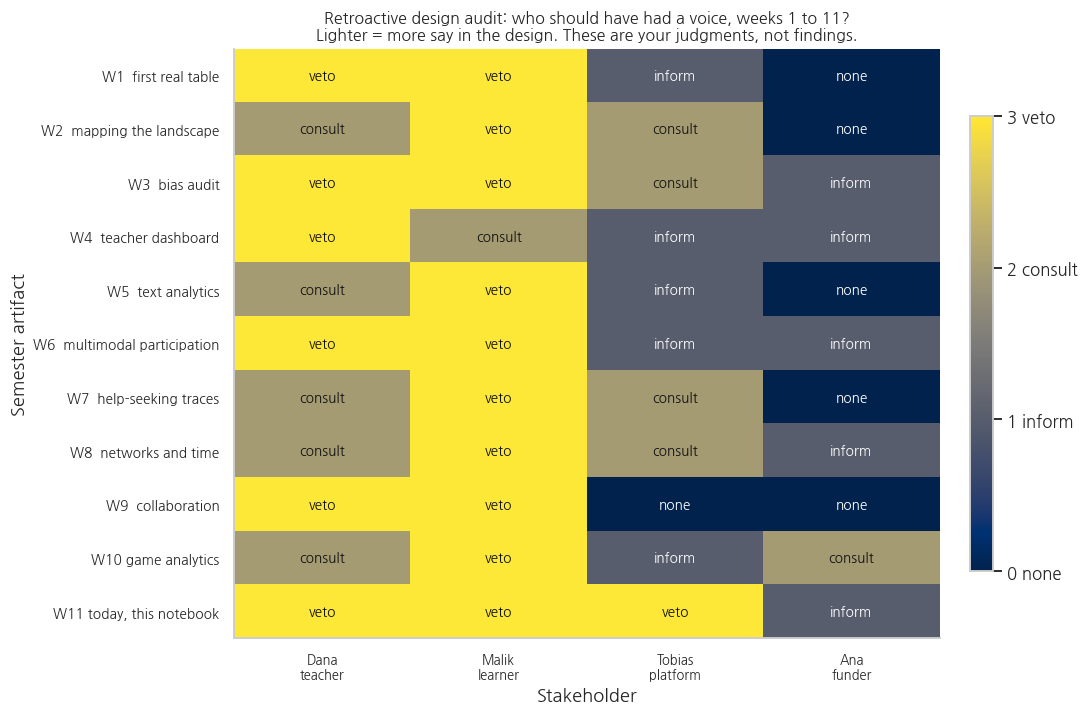

In [26]:
level_words = {0: 'none', 1: 'inform', 2: 'consult', 3: 'veto'}
fig, ax = plt.subplots(figsize=(10.0, 6.6))
z = audit_df.values.astype(float)
im = ax.imshow(z, cmap='cividis', vmin=0, vmax=3, aspect='auto')
ax.set_xticks(range(len(PERSONA_ORDER)))
ax.set_xticklabels(['{}\n{}'.format(PERSONAS[k]['name'].split()[0], k)
                    for k in PERSONA_ORDER], fontsize=8.5)
ax.set_yticks(range(len(audit_df)))
ax.set_yticklabels(list(audit_df.index), fontsize=9)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        v = int(z[i, j])
        ax.text(j, i, level_words[v], ha='center', va='center', fontsize=9,
                color='white' if v < 2 else '#111111')
ax.set_xlabel('Stakeholder')
ax.set_ylabel('Semester artifact')
ax.set_title('Retroactive design audit: who should have had a voice, weeks 1 to 11?\n'
             'Lighter = more say in the design. These are your judgments, not findings.',
             fontsize=10.5)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, ticks=[0, 1, 2, 3])
cb.ax.set_yticklabels(['0 none', '1 inform', '2 consult', '3 veto'])
plt.tight_layout()
plt.show()

**Let's look at the output.** The column totals printed above the heatmap carry more of the finding
than the colors do. In the default scoring the learner column is almost full, and every one of these
artifacts was built without a learner present. That gap between "should have had a voice" and "had a
voice" is what Prieto-Alvarez and colleagues (2018) are writing about when they argue for co-designing
*with* learners rather than for them.

Two harder questions, and both are usable in your Rough Draft:

1. Please pick the one artifact where you moved a score, and say what would have **changed about the
   artifact itself** if that stakeholder had been consulted: what would be different on the screen,
   rather than what would have felt better.
2. The last row is today. This notebook put 500 enrollments on four lists and none of those people
   were asked. The data is eleven years old and the people in it are unreachable. What is the
   smallest thing this notebook could have done differently and still been this notebook?

## Reflection

Please write a few sentences for each. They are also usable material for your Rough Draft.

**1. Design starts before the data (Carvalho, Martinez-Maldonado, Tsai, Markauskaite, and De Laat,
2022).** Their argument is that designing for learning in an AI world means starting from the
activity, its purposes, and the setting, rather than from the traces a system happens to produce.
Every measure in today's list is something a web server writes down for free, and the most common
answer people gave for why they registered has no column at all. What activity would you have had to
design first for a measure of that answer to be worth reading?

**2. Participation as a relation (Bang and Vossoughi, 2016).** Participatory design research, in their
framing, is about studying and changing relations, not about collecting stakeholder preferences and
then proceeding as planned. Looking at the actionability figure: the person the file is about can act
directly on one metric of seven, and the company that owns the file can act on four. Which relation
does your sketch reproduce, and what would have to change for the sketch to be different?

**3. Co-designing with learners (Prieto-Alvarez, Martinez-Maldonado, and Anderson, 2018).** They work
with learners as designers rather than as data sources. In your retroactive audit the learner column
carries the most weight and had the least presence. Please pick one artifact from weeks 1 to 11 and
describe, concretely, what a 45-minute co-design session with five of the people in that dataset would
have had to produce for the artifact to change.

**4. The same questions, on your own project.** Your course research project proposes a system, an
analysis, or an intervention. Who has decision rights over the thing you are proposing, and who is
measured by it? If those are different people, how does your Rough Draft handle that? Then: which
measure did you choose, and what would a defensible second measure have picked out instead?

### Your reflection

*Double-click this cell to edit it. Delete this line and write here.*

**1.**

**2.**

**3.**

**4.**

## Going further (optional)

Everything below is optional and not needed for today. Please feel free to stop here.

1. **A persona this platform has no column for.** Copy an entry in `PERSONAS`, change the key, and
   write a fifth stakeholder: a guardian of a child in the week 6 or week 10 data, a disability
   services coordinator, a translator, a research ethics board. Then add an `act_<yourkey>` column to
   `CATALOG` and redraw the actionability figure.
2. **The refusal list.** Which metrics would you decline to display to *any* of the four personas, and
   what sentence would you put in the interface where they would have gone?
3. **Two measures disagreeing about one person.** The cell below plots recorded page views against
   final grade for the survey respondents in the common population, colored by what they said they
   intended to do. The two off-diagonal corners are lists of specific people. What might a responsible
   tool do with each corner?

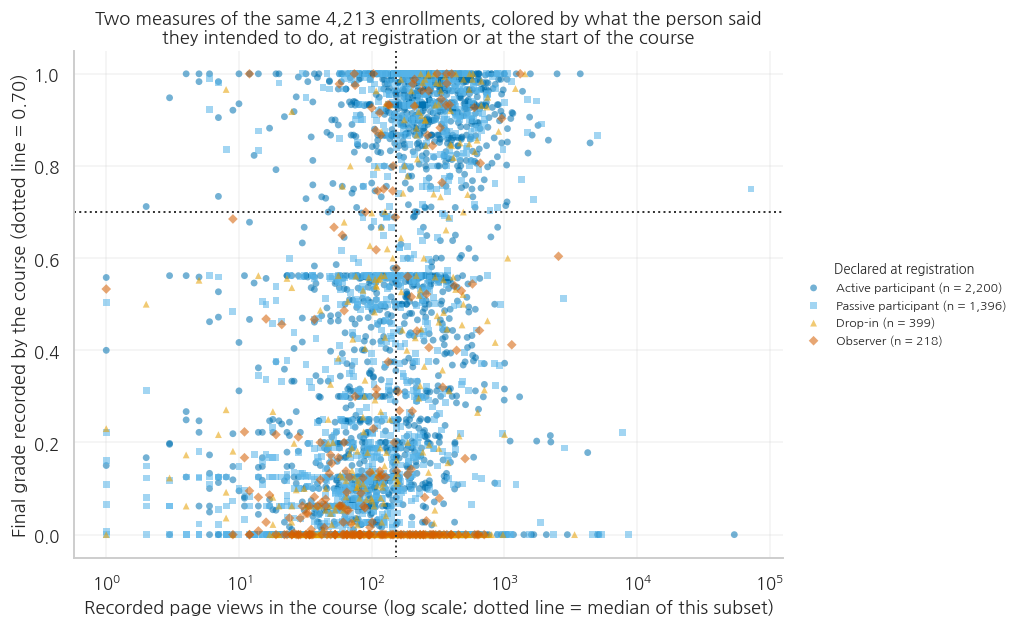

Upper-left  (few page views, grade at or above 0.70): 275 enrollments
Lower-right (many page views, grade below 0.70)     : 1,217 enrollments

Of the 1,217 in the lower-right corner, 649 (53 percent) had said they intended
to do the assignments. A dashboard built on grade places them at the bottom of its list.
A dashboard built on page views puts them on a leaderboard. Both are this file.


In [27]:
# A worked start for the third task above. Change nothing and it runs; edit it and it is yours.
sub = core[core['learner_type'].notna() & (core['learner_type'] != 'Missing')].copy()
sub['plan'] = sub['learner_type'].replace(MERGE)

fig, ax = plt.subplots(figsize=(9.4, 5.8))
styles = [('Active participant', BLUE, 'o'), ('Passive participant', SKY, 's'),
          ('Drop-in', ORANGE, '^'), ('Observer', VERM, 'D')]
for pl, colr, mk in styles:
    s = sub[sub['plan'] == pl]
    ax.scatter(s['nevents'], s['grade'], c=colr, marker=mk, s=20, alpha=0.55,
               edgecolor='none', label='{} (n = {:,})'.format(pl, len(s)))
ax.set_xscale('log')
vline = sub['nevents'].median()
hline = 0.70
ax.axvline(vline, color='#333333', linestyle=':', linewidth=1.3)
ax.axhline(hline, color='#333333', linestyle=':', linewidth=1.3)
ax.set_xlabel('Recorded page views in the course (log scale; dotted line = median of this subset)')
ax.set_ylabel('Final grade recorded by the course (dotted line = 0.70)')
ax.set_title('Two measures of the same {:,} enrollments, colored by what the person said\n'
             'they intended to do, at registration or at the start of the course'.format(len(sub)))
ax.legend(title='Declared at registration', fontsize=8, title_fontsize=8.5, loc='center left',
          bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.show()

busy_low = sub[(sub['nevents'] > vline) & (sub['grade'] < hline)]
quiet_high = sub[(sub['nevents'] <= vline) & (sub['grade'] >= hline)]
print('Upper-left  (few page views, grade at or above 0.70): {:,} enrollments'.format(len(quiet_high)))
print('Lower-right (many page views, grade below 0.70)     : {:,} enrollments'.format(len(busy_low)))
print()
print('Of the {:,} in the lower-right corner, {:,} ({:.0f} percent) had said they intended'.format(
    len(busy_low), int((busy_low['plan'] == 'Active participant').sum()),
    100 * (busy_low['plan'] == 'Active participant').mean()))
print('to do the assignments. A dashboard built on grade places them at the bottom of its list.')
print('A dashboard built on page views puts them on a leaderboard. Both are this file.')

**Let's discuss.** Neither corner is an anomaly to be explained away. Each is a list of specific
people, and the two dashboards would do opposite things to them.

Before designing anything for the Rough Draft, it is worth deciding what your system does when two of
its own metrics disagree about the same person. "Show both" is an answer only if you can say what the
reader is supposed to do with the disagreement.

## Wrapping up

**Nothing from this notebook is submitted.** Week 11 has no mini project. It is a studio, and what you
leave with is an argument you can use in your writing.

- [ ] **Save your copy.** In Colab: `File > Save a copy in Drive`. Your persona choice, your metric
      set, and your audit numbers are the record of what you decided.
- [ ] **Paste three things into your project notes**: your metric set with the one-sentence account
      of why those and not others, the one audit cell you moved with your reason for moving it, and
      the sentence you would say to Malik with your dashboard on the screen.

**Also this week, submitted on Canvas separately from this notebook:**

- [ ] **Course Research Project Rough Draft**, per the Week 11 Rough Draft Guidelines, by 11:59 PM on
      Sunday, November 8, 2026. Word document, APA 7, building toward the 20-page final.
- [ ] **AI interaction log**, pasted into a Word file and attached to the Canvas "AI Reflection"
      submission rather than into the text box. Per the course AI policy, any AI use in drafting is
      documented: the tool, the prompts, and what you did with the output.
- [ ] **AI reflection**, typed into the text box on that same page: copy in and answer the four
      questions from the syllabus. Undisclosed AI use is an Honor Code violation.

If you used an AI tool while working through this notebook, that counts and belongs in the log too.

## Appendix (optional): notes on the Your turn cells

There is no single right answer in a co-design studio, so these are **worked examples**, not keys.
It may be useful to compare your reasoning against them and note where you disagree.

### Section 4: a defensible metric set for each persona

| Persona | A defensible set | Why |
|---|---|---|
| Course team (Dana) | `ncontent`, `ndays_act`, `grade` | Modules reached tells her which parts of the course people got to, which is the question behind "which two modules do I cut". Grade is on the list because she wrote the assessment and it is hers to revise, not because it ranks anybody. |
| Learner (Malik) | `ncontent` alone | The only metric on the list he can act on directly and the only one that is about the thing he said he came for. No comparison with anyone else, which removes the fear of being ranked and loses nothing he could have used. |
| Platform (Tobias) | `nevents`, `ndays_act` | Both are genuinely his to act on and both are clear about being measures of platform usage rather than of learning. The defensible version of his dashboard is one that says so in the title. |
| Funder (Ana) | `ndays_act`, and a second measure chosen by the grantee | Active days is the closest thing here to "did the money buy sustained use". Letting the grantee name the second measure is the cheapest piece of co-design available in this whole notebook, and it costs the foundation nothing. |

One set that is hard to defend: `passed_70` on its own, for anyone. It reports a 5.4 percent success
rate on a platform where a majority of survey respondents said they were not attempting the
assignments.

### Section 5: what the four steps were for

Step 1 gave a spectacular number, and it was a true statement about the file's missingness presented
as a statement about learners. Step 2 caught that. Step 3 asked the question on a population where it
could be answered. Step 4 caught the second confound, which was that a leaderboard across 156 courses
is substantially a list of courses.

The finding that survives all four steps is the modest one, and it is still enough to run a design
session on: **holding the course constant, four defensible measures of the same enrollments produce
four largely different top-500 lists, somewhat above what course composition alone would produce and
nowhere near agreement.** Note which baseline that sentence uses. Against a uniform baseline of 11 the
same overlaps look like six to thirteen times chance; against the course-matched baseline of about 42
to 46 they look like one and a half to three and a half times it. Both numbers are arithmetically
correct and only one of them answers the question, which is whether the measures agree about **people**
rather than about courses. If your Rough Draft proposes a measure, that is the sentence its limitations
section owes the reader, and the choice of baseline is the sentence before it.

### Section 7: moving an audit cell

One move worth considering is `W10 game analytics`, on the grounds that the learners are children, so
a guardian belongs in the conversation. But there is no guardian column, so the move available
without one is to raise the `funder` or `platform` score as a proxy, which is the wrong repair. The
right repair is to add a fifth column, which is the first task under Going further. That the persona
set has to be re-opened when the learner is a child is itself a design finding worth a paragraph.

A second is the last row, this notebook, `platform` from 3 to 2 or 1, on the grounds that Canvas
Network already published the file under a license that permits exactly this. That is a real
argument. It is also an argument about a license, and a license is a thing a company grants rather
than a thing the people in the file were asked about.

### Going further: a fifth persona worth adding

The guardian of a child in the week 6 or week 10 data. Their column is almost all `3`s in the rows
where the learner is a minor and almost all `0`s everywhere else, which makes them the one persona
whose relevance is a property of the dataset rather than of the role.

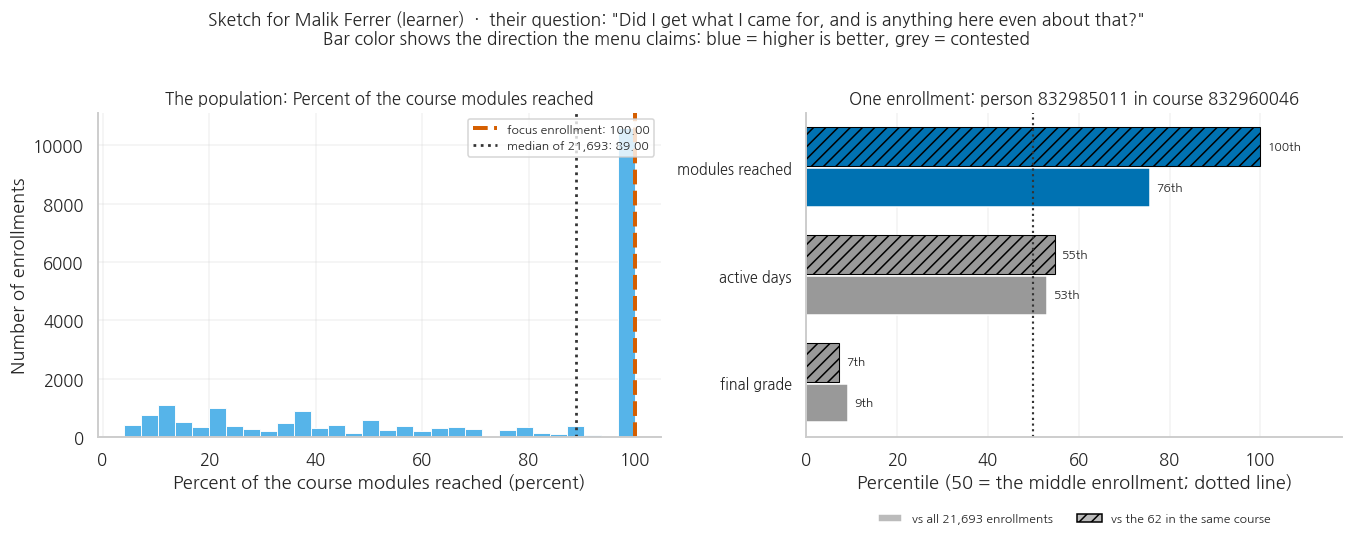

In [28]:
# Worked example for section 4: the same sketch for a different persona and metric set.
# Read the two side by side and say what changed and why.
sketch_view('learner', ['ncontent', 'ndays_act', 'grade'], FOCUS)
plt.show()

In [29]:
# Worked example for section 7: compare two audit scorings and show only where they disagree.
ALT_AUDIT = dict(AUDIT)
ALT_AUDIT['W10 game analytics'] = [2, 3, 1, 1]           # funder down: they did not commission the labeling
ALT_AUDIT['W11 today, this notebook'] = [3, 3, 1, 1]     # platform down: the license already permits this
ALT_AUDIT['W5  text analytics'] = [2, 3, 2, 1]           # platform and funder up: a test contractor held the essays

alt_df = pd.DataFrame(ALT_AUDIT, index=PERSONA_ORDER).T
diff = alt_df - audit_df
changed = diff.loc[(diff != 0).any(axis=1)]
if len(changed):
    print('Cells where the alternative scoring disagrees with yours (positive = more voice):')
    print(changed.to_string())
    print()
    print('Column totals, yours against the alternative:')
    print(pd.DataFrame({'yours': audit_df.sum(), 'alternative': alt_df.sum()}).to_string())
    print()
    print('Each of these is worth a sentence either way.')
else:
    print('Your scoring already matches this alternative. It may be worth finding someone')
    print('who scored it differently.')

Cells where the alternative scoring disagrees with yours (positive = more voice):
                          teacher  learner  platform  funder
W5  text analytics              0        0         1       1
W10 game analytics              0        0         0      -1
W11 today, this notebook        0        0        -2       0

Column totals, yours against the alternative:
          yours  alternative
teacher      28           28
learner      32           32
platform     16           15
funder        7            7

Each of these is worth a sentence either way.
